# OV7675 Image Viewer

In [2]:
# Import the needed libraries
from matplotlib import pyplot as plt
import numpy as np
import struct

In [6]:
# Copy the output of the Serial Monitor to the variable below
HEXADECIMAL_BYTES = [
0xB3,0xC1,0xB6,0xBB,0xBD,0xB6,0xC8,0xBD,0xC8,0xC8,0xBF,0xBF,0xC4,0xC3,0xC4,0xC5,0xC5,0xBD,0xC3,0xBF,0xC1,0xC3,0xCC,0xCB,0xCB,0xBF,0xCA,0xCA,0xCA,0xCA,0xCD,0xD2,0xC4,0xCD,0xC5,0xCC,0xCA,0xC5,0xCA,0xCB,0xCA,0xCC,0xCE,0xC5,0xC8,0xCA,0xC5,0xBB,0xCB,0xB6,0xC8,0xBB,0xB6,0x92,0xAB,0x9D,0xAE,0xA1,0xAE,0xB3,0xA1,0x99,0xAB,0xAE,0xAE,0xB8,0xCA,0xCF,0xD4,0xD2,0xCE,0xCF,0xCC,0xB3,0xB1,0xB6,0xBB,0xA1,0x92,0x8D,0x95,0x77,0x99,0x77,0x8D,0x77,0x74,0x5B,0x70,0xC3,0xC8,0xD2,0xCF,0xB1,0x4A,0x52,0xAB,0xB6,0xB3,0xBB,0xB6,0xB6,0xC1,0xC1,0x92,0xB3,0x86,0xCC,0xC3,0xB8,0xC5,0xC7,0xC1,0x99,0xCB,0xC8,0xC3,0xC8,0xA4,0xC3,0xBD,0xC4,0xC7,0xBB,0xC5,0xCC,0xCE,0xC8,0xCB,0xC7,0xCF,0xCB,0xC7,0xCA,0xCA,0xBB,0xD2,0xC4,0xC1,0xCE,0xCD,0xC4,0xBD,0xC4,0xC3,0xC5,0xC3,0xCA,0xCA,0xD0,0xB1,0xB3,0xB8,0xA1,0x99,0x99,0x8A,0x86,0xA7,0x8D,0x8A,0x92,0x7F,0x77,0x5F,0x86,0x77,0xCA,0x92,0xBD,0x99,0xB1,0xB3,0xAE,0xA4,0xB1,0x95,0x92,0x92,0x8A,0x8A,0x63,0x95,0x6C,0x7B,0xC4,0xCD,0xD0,0xD6,0x05,0x0B,0xB6,0xAB,0xBD,0x8D,0x99,0xB6,0xAE,0xAB,0x9D,0xB8,0xCA,0xC1,0x95,0xB6,0xC1,0xC1,0xB3,0xB1,0xAB,0xBB,0xC5,0xBB,0xC3,0xB8,0x86,0xBF,0xC5,0xCE,0xC8,0xC3,0xC4,0xBD,0xAB,0xC5,0xC8,0xBD,0xC8,0xCB,0xC5,0xCA,0xC4,0xC3,0xC4,0xC1,0xC8,0xB1,0xCA,0xC7,0xC7,0xBF,0xBB,0xC3,0xB3,0xBF,0xB8,0xB8,0xAB,0xAE,0xA7,0xC3,0xA7,0x8D,0x5F,0x82,0x8D,0x8D,0x74,0x82,0xA4,0x77,0x77,0x82,0x74,0x3A,0x7B,0x95,0x4E,0x5B,0x99,0x77,0x99,0x92,0x99,0xA1,0x8D,0x86,0x7F,0x7B,0x77,0x74,0xD2,0xD2,0xCB,0x7B,0x0E,0xBF,0xE5,0xB8,0xBB,0x99,0x92,0xB1,0xB3,0xB1,0xAE,0xA7,0x46,0xB3,0xB6,0xB6,0xAB,0xB8,0x92,0xBB,0xB6,0xB6,0xBD,0xA7,0xBB,0xB1,0x74,0xA1,0xB8,0xC5,0xB1,0xB8,0x8D,0xB8,0x8D,0xBD,0xC7,0xC4,0xCF,0xC8,0xC5,0xC1,0xCF,0xBF,0xBF,0xC4,0xC1,0xC1,0xB8,0xC4,0xAE,0xB6,0xB3,0xB6,0xAB,0xBB,0xBD,0xAE,0xBD,0xA1,0xA1,0xAB,0x92,0xA7,0xA7,0xAB,0x95,0x99,0x8A,0x77,0x7B,0x63,0x6C,0x68,0x57,0x7F,0x63,0x68,0x6C,0x5F,0x4E,0x68,0x5F,0x5B,0x77,0x57,0x4E,0x8A,0x86,0x8A,0x7F,0x74,0xD6,0xCB,0x7F,0x1C,0xA7,0xDC,0xDD,0xB3,0xB3,0xA1,0xB6,0xB3,0xAB,0xB3,0xA4,0xAE,0xB1,0x70,0xB3,0x9D,0xBF,0xB3,0xB3,0x77,0xAE,0xA4,0xC1,0xBD,0xBF,0xC4,0xBF,0xCC,0xBB,0xC3,0xC1,0xC3,0xBD,0xC7,0xCA,0xC7,0xC3,0xC1,0xC8,0xC3,0xCA,0xBF,0xC4,0xC4,0xC5,0xC3,0xBF,0xB8,0xCC,0xC5,0xBD,0xC1,0xC4,0xBB,0xC3,0xB8,0xAE,0xBD,0xAE,0xA7,0x92,0xB6,0xB1,0xAB,0xAB,0x95,0xA4,0x95,0x99,0x8D,0x9D,0x82,0x82,0x7B,0x57,0x77,0x70,0x5F,0x63,0x57,0x8D,0x68,0x42,0x4A,0x63,0x6C,0x52,0x74,0x68,0x7F,0x7B,0x8D,0xD0,0xCA,0x28,0x5B,0xE4,0xDE,0xE0,0xAE,0xAE,0xC4,0xA4,0xBD,0xA7,0xA4,0xA4,0x99,0x8D,0xA4,0xAB,0xB1,0xAB,0xAE,0xBF,0xA4,0xBB,0xCB,0xB6,0xBD,0xA1,0xC4,0xB6,0xA7,0xCC,0xC1,0xBB,0xBB,0xC7,0xB8,0xBF,0xC1,0xC8,0xC5,0xC3,0xBF,0xBD,0xCA,0xC5,0xC1,0xBF,0xCC,0xC1,0xBF,0xBB,0xC3,0xBF,0xC1,0xB6,0xB6,0xC3,0xB8,0xB8,0xB3,0xC5,0xBD,0xA1,0xA7,0x86,0xB1,0xA1,0xA1,0xA1,0xAE,0x99,0x8A,0x92,0x8A,0x8D,0x7F,0x77,0x8A,0x99,0x7B,0x5B,0x57,0x5B,0x5F,0x63,0x5F,0x3E,0x68,0x5F,0x5B,0x5F,0x52,0x52,0x52,0x6C,0x2C,0x42,0xCE,0xDA,0xDD,0xDE,0xA1,0x99,0x8D,0x99,0xB1,0x9D,0x8A,0xC4,0xB8,0xAB,0xAB,0xA7,0xAE,0xB3,0xB1,0xCF,0xB8,0xAB,0xC1,0x9D,0xB8,0xBD,0xBB,0xB8,0xAE,0xB8,0xC1,0xBD,0xCB,0x9D,0xB3,0xB6,0xBF,0xBD,0xC4,0xBF,0xC1,0xBB,0xB6,0xBB,0xBD,0xBB,0xB8,0xB6,0xB3,0xBF,0xC1,0xB6,0xBB,0xBD,0xB3,0xBB,0xB8,0xBB,0xA7,0x9D,0xB3,0xA1,0xA4,0xA1,0x9D,0x9D,0xB8,0xA7,0x8A,0xAE,0x92,0x8D,0x8A,0x86,0x82,0x77,0x99,0x77,0x52,0x70,0x74,0x68,0x68,0x6C,0x52,0x4E,0x42,0x57,0x5F,0x52,0x52,0x4A,0x4A,0x46,0x2F,0xC1,0xE4,0xDC,0xD8,0x95,0xB8,0xA1,0x99,0x8A,0xA7,0x8A,0x95,0xA4,0xAB,0x9D,0x8A,0xA1,0xB1,0xB1,0x9D,0xAE,0x95,0xB1,0xA7,0xB3,0xA4,0xA1,0xB6,0xB3,0xA7,0xA4,0x95,0x9D,0xC3,0x8D,0xC3,0xB6,0xB1,0xBD,0xBF,0xAE,0xBF,0xBF,0xC1,0xAE,0xBD,0xB3,0xB1,0xB8,0xBD,0xB3,0xC1,0xB3,0x9D,0xAE,0xB3,0xA4,0xB1,0xAE,0xAB,0xAE,0xA7,0xA7,0xA4,0xA4,0x9D,0x9D,0x99,0xAB,0x95,0xA1,0x92,0x8D,0x8D,0x6C,0x7F,0x8A,0x7B,0x7B,0x63,0x63,0x74,0x86,0x70,0x6C,0x5F,0x68,0x4E,0x5B,0x3E,0x52,0x36,0x42,0x42,0x3A,0xB8,0xDF,0xDC,0xD4,0x9D,0x8A,0x99,0x82,0xC7,0xAE,0x9D,0xA7,0x92,0xA7,0x99,0x9D,0xA4,0xA7,0xB1,0xAB,0xAB,0xAB,0xA1,0x9D,0xA7,0xAB,0x95,0xAB,0xAB,0x92,0xC4,0xB1,0xB8,0xB3,0xB6,0xA7,0xB8,0xB6,0xB3,0xB8,0xA7,0xBD,0xB6,0xB8,0xB8,0xC5,0xC1,0xB3,0xC7,0xB1,0xA4,0xAE,0xA1,0xB1,0xB3,0xB1,0xB3,0xB1,0x9D,0xA1,0xAB,0xAB,0x99,0xAE,0x8D,0x95,0x7B,0x92,0x86,0x92,0x8D,0x9D,0x8D,0x8A,0x8D,0x92,0x7B,0x7F,0x7F,0x7B,0x70,0x7B,0x70,0x99,0x52,0x5F,0x63,0x4A,0x5F,0x57,0x4A,0x57,0x3E,0x46,0x1C,0x5B,0xD4,0xD9,0xD9,0xC8,0x42,0xDE,0x8A,0x8D,0xA1,0xC1,0xA1,0xA4,0x92,0x95,0x9D,0x99,0xA1,0x9D,0xA1,0x92,0xA1,0xA7,0x92,0x9D,0x70,0xA4,0xAB,0xB1,0xA1,0xB6,0xA7,0xB6,0xA7,0xB6,0xB1,0x92,0xAB,0xB6,0xC1,0xBD,0xA4,0xB3,0xA7,0xBB,0xA1,0xAB,0xB8,0xA7,0xB1,0xAB,0xAE,0xB1,0xB3,0xA1,0xB3,0x99,0xA4,0xAB,0xA7,0xAB,0x9D,0xA1,0x9D,0x9D,0x92,0xA1,0x8D,0x9D,0x8A,0x82,0x92,0x8A,0x9D,0x82,0x86,0x7F,0x74,0x74,0x68,0x70,0x6C,0x6C,0x77,0x57,0x70,0x52,0x2C,0x68,0x70,0x42,0x4E,0x46,0x42,0x36,0x03,0xD4,0xD7,0xDD,0xD5,0x6C,0xD4,0xE3,0x95,0x74,0x8D,0x4E,0x99,0x95,0x99,0x8D,0x6C,0xB1,0xA7,0x9D,0x9D,0xA4,0xB1,0x9D,0xA4,0x99,0xAB,0xA7,0xA4,0xBD,0xC8,0x9D,0xAE,0x8D,0xC1,0x9D,0xBF,0xB8,0xAE,0xAE,0xAE,0xB8,0xBB,0xB1,0x92,0xAB,0xAB,0xAE,0xAB,0xB8,0x99,0xAE,0x8A,0xBD,0xAB,0xB3,0x8D,0x9D,0xB1,0xA1,0xA7,0x8A,0xAB,0x8A,0x95,0x92,0x92,0xA1,0x95,0x92,0x63,0x92,0x8D,0x8D,0x7B,0x95,0x7F,0x7B,0x7F,0x7F,0x7B,0x5F,0x6C,0x70,0x70,0x33,0x52,0x5B,0x99,0x5F,0x52,0x52,0x4E,0x57,0x2F,0x3E,0xCC,0xD9,0xD9,0xDD,0x6C,0xCF,0xE8,0xE2,0xA7,0x82,0x7F,0x8D,0x95,0xA1,0x95,0x8D,0x8A,0x99,0x95,0x8A,0x82,0x95,0xB1,0xA4,0x9D,0x99,0xA4,0x99,0xA4,0xA7,0x99,0xB1,0xA7,0xA1,0x74,0xBB,0xAE,0xB1,0x99,0xA7,0xA4,0xA1,0xAB,0xB1,0xB6,0xA7,0xA4,0xAB,0xB6,0xB1,0xAB,0xB3,0xA7,0x99,0xA7,0xA4,0xC8,0xA7,0xA4,0xA1,0x99,0xAB,0x92,0x77,0x95,0xA7,0xA7,0x8A,0x7F,0xA7,0x8A,0x7B,0x86,0x82,0x86,0x92,0x82,0x7B,0x42,0x74,0x7F,0x6C,0x70,0x7F,0x82,0x5F,0x52,0x4A,0x57,0x63,0x57,0x52,0x52,0x42,0x3E,0xBD,0xD4,0xD9,0xE3,0x33,0xC1,0xE5,0xE8,0xCE,0x8A,0xC4,0x82,0xC5,0xBB,0x92,0x95,0x9D,0x8D,0x99,0xB1,0x86,0x7F,0x95,0x92,0xA4,0xCC,0xA7,0xA4,0xA4,0xAB,0xAB,0xA4,0xA4,0x95,0xB6,0xC1,0xB1,0xBD,0xAE,0xBD,0xA7,0xAB,0xA1,0xCB,0xC4,0xB1,0xA7,0xA7,0xAB,0xB1,0xAB,0xAE,0xA1,0xBF,0x99,0xA4,0x95,0xA1,0xA1,0xA4,0xA7,0xBB,0x92,0x95,0x95,0x92,0xBF,0xA1,0x92,0x99,0x99,0x86,0x86,0x92,0xAB,0x8A,0x77,0x63,0x74,0x86,0x74,0x82,0x86,0x63,0x52,0x6C,0x46,0x70,0x57,0x63,0x52,0x4E,0x4E,0x4A,0x13,0x68,0xD6,0xD4,0xDB,0xBF,0xB8,0xEA,0xE4,0xE0,0x7F,0x92,0xA1,0x8A,0x8A,0x9D,0x99,0x95,0x8D,0x86,0x86,0xAE,0x99,0x86,0x82,0xAE,0x99,0xBD,0x95,0x8A,0xA1,0xA1,0xB3,0x95,0x99,0xA7,0xA4,0x99,0x8D,0x95,0xB1,0xAE,0xB3,0xA1,0xA4,0xAE,0xB3,0xBD,0xA4,0x9D,0xB8,0x99,0x99,0x9D,0x99,0x99,0xA1,0x92,0xC1,0xA1,0x82,0x9D,0x7F,0x92,0x92,0x86,0x92,0x77,0x86,0x92,0x86,0x82,0x8D,0x92,0x82,0x7F,0x82,0x8D,0x7F,0x77,0x7B,0x5F,0x70,0x7F,0x77,0x63,0x74,0x52,0x6C,0x57,0x63,0x42,0x7B,0x4E,0x5B,0x3E,0x52,0xD7,0xD7,0xD4,0x92,0xB3,0xE9,0xE3,0xD7,0x25,0x70,0xA1,0x8A,0x82,0x8A,0xA7,0x99,0x8A,0x6C,0x8D,0x92,0x92,0x77,0x7F,0x82,0x77,0x95,0x86,0x99,0x8A,0x74,0x92,0x99,0x92,0x8D,0x99,0x92,0x9D,0xA1,0xB6,0x9D,0xAE,0x95,0x82,0x7B,0x9D,0xAB,0x82,0xA7,0xCC,0x36,0xAE,0x8A,0x8D,0x74,0x8D,0xBB,0x92,0x99,0x9D,0x8A,0x95,0x8D,0x7B,0x92,0x99,0x92,0x8D,0x7F,0x7F,0x86,0x8A,0x86,0x86,0x6C,0x70,0x74,0x6C,0x7F,0x74,0x7F,0x63,0x63,0x5B,0x4E,0x74,0x5B,0x8A,0x3E,0x57,0x42,0x4E,0x4A,0x6C,0x22,0x25,0x99,0xD4,0xD3,0xC3,0x8D,0xD5,0xE1,0xE4,0x00,0x82,0x63,0x63,0x70,0xB3,0x99,0x8D,0x92,0x92,0xA4,0x92,0x92,0x95,0x68,0x8A,0x57,0x92,0x86,0x86,0x99,0x95,0xB8,0x7B,0x86,0x70,0x95,0x8A,0x92,0x82,0x99,0x8A,0x99,0x86,0xA4,0xB1,0x8A,0xAE,0xA7,0x95,0xAB,0x8A,0x95,0xA1,0x99,0x9D,0x99,0x95,0xA4,0x7F,0x8A,0x86,0x99,0x86,0x86,0x86,0x92,0x8D,0x7F,0x86,0x8A,0x7B,0x52,0x7F,0x77,0x8A,0x7B,0x74,0x74,0x70,0x68,0x63,0x4E,0x5B,0x68,0x5F,0x68,0x5B,0x4A,0x42,0x52,0x52,0x52,0x57,0x57,0x33,0x2C,0x52,0xCA,0xD2,0xD4,0x7B,0xD1,0xDF,0xDF,0xA1,0x82,0x1F,0x5B,0xAE,0xC4,0xA4,0xAB,0x63,0x86,0x99,0x99,0x5B,0xAB,0x8D,0x7B,0xA4,0x95,0x99,0x92,0x92,0x95,0xA4,0x8D,0xA7,0x95,0xA4,0x8A,0xA1,0x95,0x86,0xA1,0x9D,0x77,0xA1,0xA1,0x8D,0x9D,0x74,0x92,0xB8,0x9D,0x74,0xA1,0x99,0x77,0x8A,0x6C,0x7B,0x9D,0x82,0x8A,0x86,0x92,0x82,0x8A,0x8A,0x82,0x86,0x86,0x9D,0x5B,0x82,0x77,0x7B,0x7B,0x6C,0x70,0x52,0x6C,0x70,0x5F,0x5B,0x70,0x5F,0x63,0x7F,0x3A,0x57,0x57,0x57,0x57,0x4E,0x46,0x46,0x42,0x2C,0x46,0x77,0xCF,0xD6,0x57,0xE4,0xDD,0xDC,0x46,0x7B,0x86,0x77,0x6C,0xA7,0x9D,0x99,0x6C,0x86,0x7B,0x9D,0x63,0x92,0x95,0xB8,0x8A,0xA1,0xA4,0x92,0x86,0xA1,0x8D,0x6C,0x9D,0x86,0x92,0xA4,0x92,0xA7,0xA4,0xAE,0x8A,0x8D,0x99,0x8A,0xA1,0x8D,0xAE,0xA4,0x8D,0x95,0x99,0x86,0x9D,0xB8,0x82,0x8D,0x8A,0x86,0x70,0x86,0x8D,0x52,0x95,0x92,0xA4,0xBB,0x8A,0x7B,0x36,0x8D,0x82,0x63,0x7B,0x82,0x7B,0x70,0x6C,0x5F,0x74,0x63,0x70,0x4E,0x52,0x42,0x63,0x68,0x5B,0x4A,0x5F,0x4A,0x52,0x68,0x52,0x5F,0x22,0x57,0x74,0xCE,0xCD,0xA4,0xA7,0xDF,0xE1,0xBF,0x92,0x77,0x68,0x63,0x42,0xAB,0xAE,0xA4,0xB6,0xB6,0xB8,0xA1,0x9D,0xA4,0xB6,0xAE,0xB6,0xA7,0xA4,0xA1,0x9D,0x95,0xA4,0xB3,0xA7,0xAE,0x92,0xAB,0x92,0xA4,0xAE,0x95,0xA1,0xAE,0x9D,0x92,0x99,0x99,0x68,0x99,0x99,0x9D,0xA1,0x8D,0x86,0x92,0x92,0x8A,0x86,0x8D,0x7B,0x70,0x8D,0x95,0xB1,0x92,0x8D,0x92,0x92,0x86,0x57,0x6C,0x70,0x7F,0x6C,0x68,0x63,0x74,0x77,0x70,0x7B,0x46,0x5F,0x6C,0x68,0x92,0x46,0x4A,0x68,0x4E,0x63,0x52,0x5F,0x68,0x68,0x2C,0x2F,0x4A,0x5B,0xC4,0x68,0xCB,0xED,0xE0,0xC8,0x74,0x7B,0x68,0x68,0x63,0x16,0xBD,0xBD,0xB8,0xBF,0xCD,0xBB,0xC3,0x7B,0xAE,0x95,0xB1,0x8D,0xCA,0x86,0xAE,0xC7,0xA7,0x9D,0xA7,0xA7,0xAB,0xA7,0xAB,0xA4,0x99,0xAB,0x92,0xA4,0x92,0xA1,0xA4,0x92,0x86,0xAE,0xAB,0x92,0x99,0xA4,0x8D,0x8D,0x92,0x92,0x95,0x7B,0x99,0x8D,0x82,0x86,0x8D,0x86,0x82,0x82,0x77,0x7F,0x7F,0x8D,0x77,0x8A,0x8A,0x77,0x82,0x7F,0x82,0x70,0x74,0x74,0x68,0x5F,0x4E,0x57,0x4E,0x57,0x5B,0x57,0x5B,0x5F,0x5F,0x5B,0x4E,0x42,0x25,0x8D,0x7B,0xB1,0xBF,0x82,0xE7,0xE1,0xD1,0x6C,0x82,0x5B,0x77,0x57,0x28,0x4E,0xB3,0xB8,0xC4,0xBB,0xB8,0xCD,0xA4,0xAB,0x95,0xC3,0xB8,0xB6,0xAE,0xB8,0xBB,0xB1,0xB1,0xAE,0xBB,0xC1,0xAB,0x99,0xB3,0xA7,0xA7,0xAB,0xB8,0x9D,0x99,0xA7,0x86,0xAE,0xAE,0x9D,0xAB,0xA1,0x99,0x99,0x9D,0x99,0xA1,0x99,0x9D,0xA7,0x95,0x9D,0x86,0x8A,0x8D,0x8D,0xA1,0x8A,0x74,0x70,0x7B,0x77,0x77,0x77,0x77,0x74,0x7B,0x77,0x74,0x70,0x7B,0x6C,0x77,0x63,0x63,0x6C,0x5B,0x57,0x63,0x42,0x57,0x70,0x63,0x68,0x57,0xCF,0xD3,0xEA,0x1C,0x82,0x8D,0xD3,0xE4,0xE7,0x3A,0x86,0x70,0x68,0x63,0x46,0x57,0x92,0x77,0x82,0x9D,0x9D,0xBF,0x95,0xBB,0xBB,0xBB,0xC1,0xA4,0xBB,0xC3,0xBD,0xBB,0xBF,0x8A,0xAE,0xB6,0xB3,0xB3,0xB6,0xBF,0xB6,0xA4,0xC4,0xB6,0xA1,0xAE,0xAB,0xB1,0xAB,0xAE,0xAE,0xAB,0xA1,0xAB,0x9D,0x9D,0xA1,0x99,0x9D,0x95,0x95,0x8D,0x8D,0x7B,0x86,0xA1,0x9D,0x82,0x7F,0x82,0x82,0x7B,0x77,0x82,0x7B,0x63,0x6C,0x5B,0x5F,0x68,0x70,0x63,0x4A,0x74,0x6C,0x70,0x6C,0x6C,0x46,0x5F,0x5B,0x63,0x33,0xB6,0xD8,0xD2,0xD7,0xEC,0xFA,0x36,0x8A,0xD7,0xDB,0xE7,0x68,0x77,0x7F,0x6C,0x63,0x42,0x4A,0xAE,0xA4,0x68,0x7B,0x70,0x82,0x2F,0x4A,0x82,0xB1,0x74,0xB1,0x8A,0xC4,0xBF,0xC3,0xBF,0xA7,0xBD,0xC8,0xBB,0xB1,0xBF,0xB3,0xC1,0xB6,0xB8,0xBD,0xB3,0xB1,0xB1,0xA1,0xB8,0xAB,0xA4,0x95,0x9D,0xA1,0x8D,0xAB,0x95,0x99,0x7B,0x99,0x8A,0x92,0x92,0x9D,0x86,0x8A,0x70,0x8A,0x86,0x8D,0x77,0x82,0x70,0x77,0x70,0x74,0x68,0x6C,0x5B,0x5F,0x68,0x5F,0x3A,0x6C,0x46,0x46,0x33,0x57,0x68,0x4A,0x52,0x52,0xA1,0xE9,0xEA,0xE1,0xDA,0xD4,0xF1,0xFB,0x46,0xDF,0xDC,0xE5,0x70,0x8D,0x63,0x2C,0x63,0x46,0x3A,0x95,0x82,0x99,0x68,0x74,0x70,0x82,0x63,0x63,0x86,0xA4,0x7B,0x82,0x95,0x7F,0x92,0x5F,0xA1,0x99,0xB6,0xBD,0xBF,0xC1,0xC1,0xC5,0xC1,0xC3,0xBB,0xB3,0xC8,0xB3,0xB3,0xB3,0xAB,0xB6,0xB6,0xA7,0xB1,0xA4,0xAE,0xB1,0xA4,0x99,0x9D,0x99,0xA7,0x9D,0x92,0x9D,0xB6,0x95,0x92,0x8A,0xAB,0x8A,0x86,0x99,0x7F,0x7B,0x7F,0x8A,0x77,0x6C,0x7B,0x63,0x6C,0x7F,0x52,0x52,0x57,0x42,0x77,0x46,0x46,0x52,0x74,0x4A,0xDE,0xED,0xEC,0xE9,0xE5,0xE2,0xF2,0xF5,0xAB,0xD7,0xE0,0x99,0x77,0x70,0x5F,0x7F,0x42,0x33,0xA7,0x8D,0x9D,0xAE,0x5F,0x68,0x74,0x4A,0x68,0x74,0x92,0x8A,0x82,0x82,0x9D,0x82,0x8D,0xA4,0x7F,0x95,0x95,0xA4,0xAB,0xD2,0xD2,0xA7,0xBF,0xBF,0xB6,0xBD,0xCF,0xA7,0xBD,0xCF,0xC1,0xA7,0xBD,0xB6,0xB1,0xBB,0xAE,0xBB,0xB6,0xA1,0xAE,0xAB,0xAB,0xA7,0x92,0x9D,0x9D,0x86,0x95,0x95,0x95,0x82,0x82,0x82,0x82,0x82,0x7B,0x77,0x7B,0x68,0x68,0x6C,0x70,0x6C,0x7B,0x4E,0x5F,0x4E,0x57,0x57,0x3E,0x4A,0x7F,0x8A,0xD5,0xEE,0xEC,0xF1,0xE6,0xD9,0xEB,0xE2,0xC8,0x6C,0x7B,0x99,0x77,0x5B,0x70,0x68,0x3A,0xA1,0x99,0x9D,0xA7,0x86,0x5F,0x9D,0x4A,0x5F,0x63,0x4E,0x63,0x63,0x2C,0x6C,0xC5,0xB8,0x57,0x68,0x8A,0x86,0x8A,0x92,0x7F,0x99,0x86,0x63,0x8A,0xA1,0x95,0xAB,0xBB,0xC1,0xC8,0xC3,0xC4,0xC7,0xB8,0xBF,0xB6,0xC1,0xB1,0xB1,0xAE,0xB8,0xCC,0xC7,0xB1,0xB1,0xA1,0xA4,0xAB,0xAE,0xAE,0x92,0x99,0x99,0x8A,0x8D,0x7F,0x77,0x8A,0x8A,0x77,0x74,0x7B,0x77,0x6C,0x6C,0x5F,0x6C,0x4E,0x4A,0x5B,0x52,0x68,0x13,0x1F,0xB8,0xD8,0xEE,0xED,0xF0,0xE6,0xD4,0xF5,0xF5,0xA1,0x46,0x8A,0x63,0x5B,0x6C,0x42,0x46,0xA7,0xAE,0xB3,0xA4,0x95,0x46,0x3E,0x68,0x4E,0x4A,0x63,0x5F,0x77,0x7B,0x77,0x70,0xDE,0xDA,0x63,0x77,0x63,0x63,0x77,0x7B,0x77,0x77,0x7B,0x8D,0x8D,0xA7,0xB8,0x9D,0xAB,0x99,0xA7,0xB1,0xB6,0xBB,0xD6,0xB8,0xC3,0xBF,0xC8,0xC8,0xCB,0xB6,0xC1,0xB8,0xBD,0xB1,0xB6,0xBB,0x92,0x86,0xA7,0x82,0xAB,0x9D,0x99,0xAE,0x8D,0x86,0x86,0x8D,0x4E,0x8A,0x7B,0x6C,0x7B,0x7B,0x77,0x74,0x33,0x9D,0x5B,0x63,0xCF,0xD3,0xB8,0xD9,0xE7,0xED,0xE9,0xEA,0xE7,0xE0,0xF7,0xFD,0x1C,0x74,0x46,0x57,0x6C,0x3A,0x28,0x95,0xA7,0x99,0xB1,0xC5,0x3A,0x2C,0x4A,0x22,0x57,0x46,0x2F,0x42,0x4A,0x70,0x10,0x4E,0xE3,0xD8,0x57,0x5B,0x7B,0x68,0x63,0x63,0x74,0x68,0x68,0x68,0x70,0x7B,0x8A,0x8A,0x8A,0x86,0x74,0x86,0x6C,0x7B,0x92,0xA1,0x77,0x9D,0xA1,0x92,0xCD,0xC1,0xBB,0xC1,0xB8,0xC3,0xB8,0xBF,0xAB,0xB3,0xB8,0xB6,0xAB,0xA1,0xC8,0xB3,0xA1,0xAB,0x7F,0x9D,0x95,0x92,0x7B,0x70,0x7B,0x7B,0x7F,0x7B,0x68,0x63,0x70,0x0E,0xE5,0xE7,0xE6,0xDD,0xEF,0xEC,0xE6,0xE1,0xCA,0xED,0xF5,0xFD,0x02,0x77,0x36,0x68,0x3A,0x42,0xC4,0xA1,0xA1,0xA7,0x82,0x4E,0x1C,0x68,0x46,0x46,0x42,0x2C,0x46,0x3E,0x5B,0x52,0x74,0xCD,0xE4,0xD1,0x5B,0x52,0x10,0x57,0x7F,0xBB,0x13,0x3A,0x6C,0x68,0x6C,0x5B,0x7B,0x70,0x82,0x7B,0x74,0x70,0x7F,0x57,0x99,0x8D,0x77,0x70,0x92,0x92,0x9D,0x77,0x9D,0x95,0x86,0xC1,0xC4,0xBB,0xC5,0xB6,0xAB,0xAB,0xB8,0xB1,0xA4,0xA7,0x92,0xA7,0x82,0x92,0x70,0x82,0x8A,0x4A,0x82,0x86,0x77,0x7B,0x70,0x5B,0x63,0x86,0xAB,0xE4,0xEE,0xE5,0xEB,0xE9,0xDE,0xE1,0xCC,0xED,0xF5,0xFC,0x04,0x3A,0x36,0x52,0x46,0x63,0x92,0x95,0xB3,0x8A,0x33,0x22,0x2F,0x3E,0x5F,0x42,0x16,0x3E,0x46,0x3A,0x52,0x42,0x74,0xD6,0xE4,0xC5,0x86,0x3E,0x63,0x63,0x63,0x3E,0x4E,0x3A,0x5F,0x57,0x5B,0x5F,0x77,0x7F,0x92,0x7F,0x7F,0x7B,0x7B,0x28,0x68,0x7B,0x5B,0x68,0x4E,0x74,0x7F,0x8D,0x8A,0x92,0x5B,0x70,0x86,0x86,0x82,0x95,0x82,0xAE,0xAB,0xB8,0xB8,0xA7,0xAE,0xAE,0xAB,0xA1,0x99,0xB3,0x95,0x82,0x95,0x86,0x82,0x7B,0x9D,0x77,0x63,0x77,0x82,0xE9,0xEC,0xE8,0xEB,0xE9,0xE1,0xCF,0xEA,0xE5,0xF4,0xFD,0x16,0x28,0x36,0x04,0xB3,0x82,0x8D,0xA7,0x9D,0x1C,0x28,0x1C,0x4A,0xA1,0x5F,0x3A,0x6C,0x57,0x5B,0x4E,0x77,0x70,0x92,0xED,0xE5,0xD0,0x1F,0x77,0x70,0x6C,0x4A,0x4A,0x46,0x5B,0x68,0x5F,0x70,0x70,0x70,0x6C,0x46,0x74,0x57,0x74,0x68,0x77,0x7B,0x70,0x57,0x70,0x70,0x63,0x7B,0x86,0x77,0x7B,0x82,0x82,0x7B,0x7F,0x99,0x86,0x82,0xAB,0x74,0x5F,0x5F,0xA4,0xA7,0xB1,0xA4,0xA1,0xB3,0xAB,0x99,0xA7,0x8D,0x92,0x8D,0x86,0x82,0x8D,0x86,0x8D,0xCF,0xE1,0xE8,0xE4,0xEC,0xED,0xE8,0xDC,0xF4,0xEB,0xFA,0xFD,0x28,0x1F,0x1F,0x6C,0x86,0x63,0x95,0x63,0x5F,0x19,0x42,0x33,0x3E,0x2C,0x70,0x77,0x5B,0x42,0x52,0x5B,0x70,0x8D,0xB8,0xE3,0xED,0x7B,0x46,0x77,0x74,0x68,0x52,0x57,0x36,0x46,0x3E,0x3A,0x1F,0x36,0x70,0x4E,0x63,0x52,0x57,0x68,0x68,0x6C,0x6C,0x68,0x63,0x5F,0x5F,0x57,0x68,0x77,0x63,0x63,0x5F,0x63,0x74,0x70,0x74,0x6C,0x74,0x5B,0x86,0x99,0x63,0x70,0x6C,0x63,0x3A,0x70,0x74,0xB3,0xAE,0x99,0x8D,0x99,0x82,0x82,0x7B,0x82,0x7B,0xB1,0xAB,0xE1,0xEA,0xCB,0xF5,0xE9,0xEB,0xED,0xF6,0xEA,0xF7,0xFB,0x0E,0x04,0x2F,0x77,0x86,0x8A,0x63,0x3E,0x0E,0x1C,0x3E,0x4E,0x2F,0x10,0x74,0x8D,0x82,0x74,0x7B,0x33,0x92,0xA4,0xB1,0xF1,0xE4,0x4E,0x63,0x8A,0x70,0x7B,0x74,0x5F,0x42,0x4E,0x4E,0x52,0x52,0x68,0x3E,0x16,0x57,0x57,0x57,0x42,0x4A,0x4E,0x5B,0x3A,0x3A,0x86,0x57,0x68,0x63,0x68,0x99,0x4E,0x36,0x68,0x77,0x68,0x68,0x74,0x77,0x70,0x68,0x52,0x57,0x4A,0x52,0x57,0x57,0x57,0x6C,0x52,0x57,0x57,0x5B,0x5F,0x7B,0x7F,0x7F,0x8D,0x8D,0xB8,0xDF,0xE8,0xDF,0xA1,0xEE,0xE8,0xEB,0xF1,0xF7,0xE2,0xF2,0xF9,0x25,0x13,0x3A,0x74,0x7B,0x74,0x3A,0x28,0x13,0x19,0x2F,0x3E,0x33,0x0B,0xC1,0xC7,0x82,0x99,0x86,0x8D,0x63,0xA7,0x74,0xE7,0xDC,0x70,0x82,0xB3,0x95,0x99,0x6C,0x57,0x5F,0x3E,0x70,0x5F,0x7B,0xC5,0xD2,0xCE,0x74,0x8A,0x68,0x36,0x42,0x46,0x57,0x57,0x5B,0x52,0x5F,0x46,0x57,0x5B,0x4A,0x63,0x57,0x52,0x63,0x6C,0x68,0x5F,0x74,0x63,0x63,0x68,0x57,0x4A,0x3E,0x3E,0x46,0x4E,0x3E,0x4E,0x57,0x52,0x52,0x5F,0x4A,0x4A,0x57,0x42,0x4A,0x6C,0xF1,0xF3,0xCC,0xED,0xEB,0xE7,0xED,0xF3,0xF6,0xE3,0xFA,0xF1,0x1F,0x16,0x57,0x68,0x5B,0x2C,0x16,0x1F,0x13,0x1F,0x2F,0x36,0x42,0x28,0xC1,0x9D,0x57,0xA7,0xAE,0xBF,0xBF,0xC5,0xC4,0xE4,0xD3,0x3E,0xCF,0xD0,0xCF,0x99,0x74,0x7F,0xE7,0x5F,0xEB,0x08,0x92,0xDD,0xD4,0xD0,0x95,0x86,0x70,0x86,0x99,0x4E,0x4E,0x5F,0x5F,0x3E,0x4E,0x57,0x57,0x3E,0x3E,0x3E,0x46,0x42,0x3E,0x52,0x3E,0x4E,0x57,0x42,0x7F,0x68,0x42,0x46,0x4A,0x42,0x3E,0x46,0x4A,0x3E,0x3E,0x3A,0x3A,0x33,0x57,0x0E,0x06,0x3E,0x2F,0x46,0xED,0xD8,0xD3,0xF1,0xEC,0xE6,0xEF,0xF7,0xF6,0xE3,0xF6,0xEC,0x1C,0x16,0x2F,0x4A,0x05,0x16,0x0B,0x13,0x13,0x22,0x2C,0x1F,0x33,0x28,0xDF,0xCE,0xC8,0xA7,0x7F,0xC7,0xD3,0xA1,0xD8,0xE9,0xC3,0xA7,0xE1,0xCF,0xD5,0xB1,0x77,0x8A,0xFE,0xAB,0xFE,0xFE,0x77,0xDA,0xDC,0xC7,0xB8,0xB6,0x9D,0x7F,0x68,0x68,0x2F,0x5B,0x5B,0x7F,0x5F,0x74,0x82,0x99,0xC8,0x0B,0x22,0x57,0x2C,0x3A,0xB3,0x7F,0x99,0x3E,0xAE,0x63,0x33,0x33,0x1F,0x42,0x33,0x3E,0x3A,0x25,0x33,0x46,0x4E,0x3E,0x36,0x05,0x1F,0x36,0x3E,0x10,0xED,0xEF,0xF9,0xF3,0xEB,0xE9,0xF2,0xF9,0xF5,0xE0,0xFB,0xD2,0x1C,0x19,0x1C,0x19,0x03,0x13,0x0E,0x1F,0x25,0x10,0x25,0x02,0x4A,0x1C,0xD8,0xDD,0xDB,0xE7,0xDE,0xE3,0xE3,0xD3,0xDB,0xE6,0x99,0xC8,0xF2,0xC3,0xEF,0xA4,0xBB,0x7F,0xFD,0x95,0xFE,0xFE,0xC5,0xEA,0xE7,0xD2,0xD3,0xD8,0x82,0xAE,0x63,0xEF,0xD2,0x68,0x57,0x36,0x5B,0x68,0x77,0xAE,0xB3,0x4A,0x46,0x33,0x0B,0x74,0xAE,0x9D,0xC3,0x42,0xC5,0xA7,0x25,0x25,0x25,0x25,0x13,0x2C,0x33,0x28,0x19,0x2F,0x25,0x1C,0x1F,0x42,0x28,0x4A,0x3A,0x19,0xF0,0xED,0xF8,0xF3,0xEC,0xE6,0xF0,0xF1,0xF7,0xE0,0xF4,0xD0,0x08,0x1C,0x16,0x10,0x05,0x0E,0x0E,0x0B,0x13,0x13,0x22,0x13,0x25,0x1F,0x74,0x7F,0x5F,0xB3,0xC4,0xCA,0xDC,0xE9,0xE6,0xE4,0xDA,0xE0,0xEB,0xDA,0xEC,0x16,0xBD,0xE2,0xFA,0xD6,0xF6,0xE0,0xD8,0xF5,0xF3,0xCF,0xE2,0xDB,0xCF,0xCD,0xBF,0xFE,0xED,0xB1,0x5F,0x74,0x4A,0x8D,0xD6,0xB8,0x6C,0x8D,0x4A,0x28,0x3E,0xC1,0xC3,0xBB,0xCD,0x3A,0xDF,0xB3,0x46,0x3A,0x33,0x28,0x25,0x25,0x2C,0x36,0x1F,0x16,0x25,0x19,0x3E,0x2F,0x36,0x28,0x42,0x3A,0xEC,0xF2,0xF8,0xE7,0xEE,0xDC,0xF1,0xF6,0xF7,0xE2,0xF2,0xCA,0x22,0x1C,0x13,0x06,0x06,0x16,0x1C,0x0E,0x13,0x19,0x28,0x25,0x3E,0x2C,0x74,0x5B,0x6C,0x68,0x82,0x7F,0x8A,0x74,0xEB,0xD9,0xB6,0xC3,0xEE,0xF7,0xF7,0xFA,0xF7,0xF0,0xF3,0xF4,0xE4,0xD5,0xF2,0xFC,0xF7,0xD8,0xE7,0xE0,0xE7,0xD7,0xD4,0xFF,0xFE,0xD5,0x68,0xA1,0xC5,0xC7,0xFB,0xD1,0xB6,0xB1,0xBB,0x52,0x70,0xB1,0xAB,0xCD,0xD3,0x86,0xE5,0xC4,0x57,0x33,0x4E,0x4A,0x28,0x2C,0x22,0x1F,0x2C,0x28,0x25,0x22,0x2C,0x2C,0x28,0x2F,0x2F,0x13,0xEC,0xF5,0xF6,0xD4,0xEF,0xD8,0xF1,0xF9,0xF5,0xE3,0xF8,0xCC,0x25,0x28,0x16,0x16,0x04,0x16,0x19,0x16,0x13,0x13,0x1C,0x2C,0x4A,0x01,0x4E,0x42,0x5F,0x5B,0x57,0x68,0x70,0xCB,0xE9,0xD9,0x3E,0x68,0x5F,0x86,0x33,0x4A,0x9D,0xE5,0xE7,0xF8,0xF6,0xF0,0xF6,0xF6,0xF6,0xEF,0xF3,0xDD,0xE3,0xDE,0xD3,0xD7,0x7B,0xED,0x68,0xC4,0xD6,0xD0,0xEE,0x42,0xAE,0xC7,0x92,0x74,0x6C,0xD8,0xD2,0xE1,0xE2,0xC3,0xE7,0x74,0x36,0x33,0x46,0x33,0x1C,0x16,0x2C,0x2C,0x25,0x36,0x13,0x33,0x1C,0x2C,0x2F,0x19,0x22,0x13,0xEC,0xF7,0xF6,0xE3,0xF0,0xD8,0xF2,0xF5,0xF3,0xE1,0xE6,0xCB,0x04,0x28,0x1C,0x10,0x0B,0x10,0x16,0x0E,0x0B,0x13,0x16,0x25,0x33,0x33,0x52,0x4A,0x4A,0x4A,0x52,0x4E,0x6C,0xD7,0xE4,0xC1,0x3E,0x4E,0x68,0x25,0x68,0x68,0x3A,0x86,0x1F,0x63,0x1F,0x3E,0xAE,0xDC,0xF1,0xEF,0xFB,0xFC,0xF0,0xF2,0xF1,0xE5,0xCE,0xE4,0xA4,0xC7,0xD0,0xE9,0xEB,0xB6,0xC4,0xBD,0xBB,0x7F,0xA7,0xF9,0xEF,0xEC,0xFB,0xC3,0xEB,0x7F,0x2C,0x57,0x36,0x28,0x5F,0x0B,0x3E,0x36,0x2F,0x2F,0x36,0x10,0x3E,0x2C,0x16,0x46,0x52,0x2C,0xED,0xF5,0xF4,0xE0,0xEE,0xDC,0xE8,0xF7,0xF3,0xE6,0xE4,0x86,0x02,0x2C,0x19,0x13,0x0B,0x19,0x25,0x16,0x19,0x19,0x19,0x25,0x2F,0x42,0x3A,0x3A,0x52,0x42,0x4E,0x19,0x70,0xD9,0xE7,0xAE,0x4A,0x36,0x42,0x46,0x52,0x4A,0x5B,0x70,0x6C,0x5F,0x5B,0x4A,0x74,0x6C,0x77,0x68,0x3E,0x8D,0xBD,0xD3,0xE0,0xE1,0xF1,0xEE,0xEF,0xE9,0xED,0xE7,0xE5,0xD7,0xD4,0xD4,0xCB,0x6C,0xB6,0xF4,0xF1,0xFC,0xFE,0xCF,0xF1,0x82,0x5B,0x4E,0x42,0x36,0x36,0x3A,0x19,0x25,0x3A,0x3A,0x3A,0x3A,0x1C,0x33,0x28,0x25,0x33,0x16,0xF2,0xEA,0xF1,0xE0,0xE4,0xDD,0xE5,0xF8,0xF5,0xF2,0xE0,0x82,0x00,0x3A,0x22,0x0B,0x0E,0x13,0x0B,0x13,0x1C,0x1C,0x19,0x28,0x3A,0x22,0x46,0x22,0x36,0x4A,0x5F,0x4E,0x70,0xEB,0xE9,0x52,0x3A,0x4A,0x42,0x3E,0x42,0x57,0x42,0x86,0x7F,0x4A,0x4A,0x28,0x3E,0x4A,0x68,0x6C,0x68,0x68,0x52,0x2F,0x7F,0x52,0x16,0x42,0x74,0xC7,0xD7,0xD7,0xE2,0xF0,0xE6,0xE1,0xE9,0xE2,0xD3,0xF3,0xFB,0xFE,0xFE,0xC5,0xE9,0x68,0x82,0x5F,0x5B,0x4E,0x4E,0x57,0x57,0x52,0x63,0x52,0x36,0x46,0x2C,0x4E,0x57,0x46,0x4A,0x06,0xF5,0xE4,0xEE,0xE7,0xDE,0xD8,0xE3,0xFA,0xF4,0xF6,0xDD,0x22,0x0E,0x2C,0x1C,0x19,0x10,0x16,0x08,0x0E,0x16,0x1C,0x1C,0x0E,0x3A,0x28,0x5B,0x42,0x3A,0x4A,0x4E,0x46,0xB1,0xE5,0xED,0x28,0x28,0x4A,0x36,0x3A,0x3E,0x46,0x46,0x33,0x42,0x46,0x4E,0x57,0x52,0x4E,0x3E,0x52,0x63,0x63,0x6C,0x68,0x57,0x63,0x5F,0x99,0x6C,0x6C,0x74,0x77,0x70,0x95,0x82,0xA4,0xB8,0xCE,0xDC,0xDB,0xE5,0xEA,0xDE,0xD8,0xDD,0xC3,0xA1,0x7F,0x4E,0x68,0x36,0xBF,0x9D,0xCF,0x5F,0x7B,0x28,0x57,0x36,0x5B,0x5F,0x42,0x36,0xD2,0xED,0xE1,0xEE,0xE9,0xE0,0xD6,0xE2,0xFA,0xF4,0xF9,0xDA,0x3E,0x0B,0x22,0x25,0x19,0x1C,0x19,0x0E,0x16,0x19,0x0E,0x19,0x28,0x36,0x2F,0x05,0x05,0x1F,0x52,0x3A,0x33,0xEA,0xE4,0xE7,0x86,0x63,0x5B,0x42,0x3E,0x4A,0x2C,0x3E,0x36,0x36,0x3E,0x46,0x3A,0x3E,0x42,0x42,0x25,0x1F,0x4E,0x3E,0x3A,0x42,0x42,0x4E,0x46,0x4E,0x5F,0x3A,0x3A,0x5B,0x5F,0x57,0x4E,0x28,0x4A,0x10,0x3A,0x25,0x95,0xB6,0x9D,0xB1,0xD2,0xDC,0xD0,0xCA,0xC8,0xC3,0xC8,0xC7,0xD5,0x28,0x5B,0x1F,0x6C,0x1F,0x4A,0x4E,0x28,0xEA,0xDF,0xEA,0xE7,0xED,0xF1,0xE4,0xD7,0xDA,0xFA,0xF5,0xFA,0xD8,0x3A,0x36,0x28,0x25,0x13,0x10,0x16,0x01,0x08,0x13,0x13,0x19,0x1C,0x33,0x25,0xC8,0xE8,0xC3,0xB1,0x82,0xCF,0xE1,0xE2,0xE1,0x9D,0x8A,0x8D,0x70,0x70,0x46,0x7B,0x77,0x2F,0x25,0x0E,0x3A,0x46,0x36,0x0E,0x2F,0x3A,0x63,0x3E,0x3E,0x2C,0x3E,0x36,0x06,0x4A,0x57,0x33,0x9D,0x2C,0x42,0x57,0x3E,0x4A,0x3A,0x52,0x57,0x5F,0x5F,0x42,0x5B,0x57,0x42,0x36,0x3E,0x57,0x22,0x63,0x95,0xB1,0xBD,0xC5,0xC3,0xA1,0xB8,0x8D,0x6C,0x95,0x99,0xF7,0xE7,0xE6,0xE5,0xE9,0xEF,0xF8,0xDF,0xDF,0xD6,0xF9,0xF3,0xFA,0xD6,0x9D,0x25,0x13,0x2F,0x0E,0x1F,0x19,0x10,0x13,0x0B,0x16,0x19,0x1C,0x2F,0x1C,0xD8,0xDD,0xCD,0xC7,0xA1,0xD8,0xDE,0xE4,0xCB,0xD3,0x22,0xDD,0xD4,0xD0,0x9D,0x9D,0xAE,0x8D,0x74,0x9D,0x82,0x4A,0x52,0x63,0xCA,0xA4,0x74,0x1C,0x3E,0x25,0x42,0x46,0x36,0x2C,0x1F,0x3E,0x2C,0x46,0x5B,0x2F,0x36,0x3E,0x2C,0x5B,0x46,0x4A,0x57,0x2C,0x57,0xF2,0xF1,0x3A,0x3A,0x2F,0x42,0x52,0x42,0x3E,0x2F,0x36,0x70,0x7B,0x7F,0xA4,0xBF,0xBF,0xBD,0x9D,0xA7,0x52,0xEB,0xEC,0xF1,0xEE,0xED,0xE5,0xD4,0xF8,0xF3,0xF9,0xDF,0x74,0x5B,0x3E,0x46,0x16,0x1C,0x16,0x0E,0x13,0x10,0x16,0x19,0x1C,0x28,0x1C,0xE5,0xC1,0x74,0x92,0x74,0xE9,0xE2,0xE9,0xBF,0xE1,0xC5,0xDE,0xDC,0xD8,0xAB,0xE8,0xDD,0xB3,0xB1,0xC3,0x82,0x70,0x52,0xBD,0xCF,0xBF,0x68,0x74,0x68,0xC4,0xCA,0x57,0x4E,0x46,0x28,0x3A,0x33,0x3A,0x28,0x28,0x2F,0x3A,0x5B,0x22,0x28,0x3A,0x2F,0x3A,0x04,0xF8,0xEF,0x3A,0x3A,0x4A,0x2F,0x3A,0x33,0x42,0x46,0x57,0x3A,0x42,0x42,0x3E,0x42,0x52,0x5B,0x57,0x5F,0x1C,0xED,0xEB,0xF3,0xEF,0xEF,0xEA,0xCF,0xF7,0xF3,0xF7,0xE4,0x77,0x42,0x33,0x13,0x08,0x10,0x1C,0x1C,0x13,0x10,0x1F,0x19,0x16,0x33,0x00,0xDE,0x36,0xBF,0x8A,0xA4,0xEB,0xDF,0xE1,0x8D,0xC8,0xC3,0xDD,0xDC,0xD6,0xD4,0xCB,0xE6,0xCE,0xD5,0xDE,0xCB,0x95,0xCE,0xF3,0xF9,0xF3,0x70,0x5F,0x68,0xDC,0x52,0xCB,0x5B,0x46,0x42,0x42,0x33,0x3A,0x42,0x28,0x36,0x36,0x36,0x77,0x3A,0x28,0x2C,0x1F,0x02,0xFC,0xDF,0x0B,0x4A,0x25,0x36,0x2C,0x2F,0x2F,0x33,0x2C,0x2C,0x33,0x3E,0x3A,0x33,0x3E,0x2C,0x42,0x46,0x1F,0xEB,0xEC,0xEF,0xF1,0xF3,0xF1,0xC7,0xF8,0xF1,0xF2,0xE4,0xBF,0x70,0x28,0x19,0x25,0x16,0x1C,0x1F,0x13,0x0E,0x19,0x16,0x10,0x22,0x10,0xF9,0x13,0xA1,0x86,0x5F,0xE4,0xE1,0xD7,0xA4,0xAE,0xCF,0xDA,0xDC,0xDA,0xDA,0xD2,0xED,0x92,0xD6,0xDC,0x74,0xA7,0x68,0xFE,0xF8,0xCC,0xAB,0xF6,0xA1,0xEF,0x86,0xF8,0x77,0x68,0x3E,0x4E,0x33,0x2C,0x42,0x42,0x52,0x5F,0x6C,0x5B,0x4A,0x42,0x10,0x0B,0x19,0xFB,0xD4,0x28,0x16,0x28,0x22,0x1C,0x19,0x2F,0x2F,0x2F,0x28,0x1C,0x2C,0x36,0x36,0x3A,0x2F,0x46,0x36,0x02,0xED,0xED,0xEF,0xF5,0xFA,0xF0,0xCD,0xF8,0xF1,0xED,0xDA,0xBB,0x57,0x25,0x36,0x16,0x0B,0x19,0x16,0x0B,0x10,0x19,0x13,0x13,0x13,0x1F,0xF8,0x86,0xA7,0xA7,0xCE,0xDE,0xF4,0xCF,0x8D,0x92,0xBF,0xDB,0xCD,0xD7,0xD7,0xDD,0xF0,0x7F,0xE8,0xDA,0x92,0xA7,0x4A,0xFE,0xFD,0xC8,0xC4,0xE2,0x7B,0xFD,0xFB,0xE9,0xD8,0xD4,0xCE,0xC3,0xAB,0x57,0x4A,0x68,0x74,0x68,0x7F,0x77,0x3E,0x08,0xD7,0xC8,0x10,0xF6,0x86,0x36,0x2C,0x2C,0x28,0x28,0x2F,0x2C,0x22,0x25,0x25,0x22,0x2F,0x25,0x33,0x36,0x33,0x42,0x2F,0x01,0xEC,0xED,0xF1,0xEF,0xFB,0xED,0xA7,0xF8,0xF1,0xF3,0xDF,0xAE,0x63,0x1F,0x2F,0x16,0x0E,0x1C,0x25,0x1C,0x0E,0x16,0x19,0x10,0x28,0x19,0xCB,0x4E,0xA7,0x9D,0xCB,0xD4,0xE4,0xDB,0x99,0x8D,0xCD,0xDA,0xBB,0xD1,0xD9,0xD6,0xF5,0x95,0xE9,0xF0,0x7F,0x3A,0x1C,0xE0,0xE9,0xDB,0x52,0x7B,0xCD,0xFD,0xF9,0xE8,0xF1,0xF1,0xE4,0xD1,0xAB,0x70,0xA1,0x82,0xC8,0x95,0xA1,0x8D,0xD6,0x13,0xEF,0xCB,0x13,0xED,0x74,0x3E,0x42,0x28,0x2F,0x16,0x2C,0x25,0x1F,0x1C,0x1F,0x25,0x25,0x22,0x3A,0x2C,0x46,0x46,0x46,0x25,0xEA,0xE5,0xEF,0xEB,0xFA,0xF1,0x9D,0xF8,0xEF,0xF7,0xE8,0xC4,0x7F,0x2F,0x36,0x13,0x0E,0x19,0x19,0x10,0x10,0x08,0x0E,0x0E,0x63,0x16,0x99,0x52,0x82,0x7F,0xA7,0x82,0x5F,0x92,0x95,0x57,0xD8,0xE1,0xBD,0xD3,0xDA,0xE4,0xF3,0x5F,0xD6,0xDD,0xAE,0x4A,0x22,0xDF,0xD1,0x33,0x1F,0xA4,0xD1,0xFC,0xF8,0xEA,0xF4,0xF5,0xD0,0xC4,0x68,0x68,0x8A,0x99,0xC3,0x3E,0x92,0x68,0xE1,0x22,0xFB,0xFE,0xBB,0xEA,0x74,0x2F,0x42,0x3A,0x2F,0x46,0x33,0x28,0x28,0x25,0x1C,0x28,0x25,0x22,0x2C,0x4A,0x5B,0x5B,0x36,0x2C,0xE7,0xE2,0xF0,0xE9,0xF8,0xF8,0xBD,0xF4,0xEF,0xF3,0xE7,0xC4,0xB8,0x25,0x1F,0x16,0x19,0x19,0x16,0x10,0x13,0x1F,0x13,0x16,0x33,0x16,0xC1,0x92,0xA1,0xB1,0xBF,0xC7,0x8D,0x7B,0xBD,0xD9,0xDC,0xD4,0xCF,0xBD,0xD8,0xF4,0xF6,0xB3,0xD8,0xD5,0xC7,0x46,0x7F,0xDB,0xCA,0xB6,0x8A,0xCB,0xDC,0xFE,0xFD,0xDA,0xF3,0xF5,0xA1,0xBD,0x77,0x7F,0x3A,0x52,0xC8,0x92,0xB1,0x92,0xDC,0x92,0xFD,0xFE,0xD8,0xE9,0x70,0x68,0x22,0x70,0x2F,0x57,0x28,0x46,0x36,0x36,0x2F,0x19,0x57,0x42,0x33,0x4A,0x68,0x68,0x36,0x22,0xEB,0xD2,0xF0,0xE4,0xFB,0xF6,0xD1,0xF3,0xED,0xF7,0xE5,0xCA,0xCA,0x28,0x2F,0x10,0x08,0x33,0x16,0x10,0x25,0x16,0x19,0x0B,0x3A,0x0B,0x68,0x77,0x19,0x3E,0x6C,0x8D,0xA1,0x4A,0x5F,0x8A,0xCE,0xD4,0xDF,0xDD,0xDB,0xE4,0xE7,0xE2,0xE4,0xDC,0xC3,0x01,0x63,0xD2,0xB1,0xCD,0x74,0x5B,0xE9,0xF9,0xF1,0xDD,0xF6,0xF9,0x9D,0xCE,0x3A,0x63,0x5B,0x74,0xBD,0x63,0xB6,0x7F,0xDD,0xCC,0xEF,0xFE,0xD3,0xEC,0x52,0x42,0x42,0xCE,0xBD,0x2C,0x01,0xD2,0x7F,0x5F,0x28,0x8A,0xC4,0x0E,0x7F,0x92,0x74,0x70,0x5B,0x28,0xE7,0xB8,0xEF,0xE2,0xFA,0xF7,0xB1,0xF4,0xED,0xF3,0xEB,0xB8,0xB6,0x1F,0x28,0x02,0x08,0x02,0x13,0x0B,0x08,0x16,0x0E,0x0B,0x28,0x04,0x68,0x4E,0x46,0x5F,0x4A,0x3E,0x7F,0xA4,0x7F,0x6C,0xB6,0xC7,0x2C,0x77,0x95,0xBD,0xE7,0xEE,0xEE,0xF3,0xEF,0xF6,0xEF,0xF2,0xED,0xB8,0x52,0x28,0xD8,0xED,0xE3,0xF3,0xF7,0xFC,0x77,0xC8,0x77,0x68,0x86,0x2F,0x99,0x92,0x86,0x7B,0xD2,0xD4,0xEE,0xFE,0xD4,0xF0,0x33,0x1C,0x92,0xAB,0xCB,0x46,0x13,0xED,0xE9,0xE4,0xD2,0xE3,0x74,0x16,0xD1,0x77,0x86,0x5F,0x8D,0x5F,0xE8,0x6C,0xF0,0xD5,0xF6,0xF6,0xB8,0xF3,0xED,0xF1,0xDE,0xBD,0xCE,0x33,0x28,0x16,0x10,0x16,0x1C,0x1C,0x0B,0x1F,0x16,0x10,0x22,0x0B,0x46,0x4E,0x52,0x2C,0x46,0x46,0x77,0x8D,0x7F,0x99,0x77,0xA1,0x5B,0x68,0x5B,0x74,0x28,0x77,0x3E,0x86,0x86,0xA4,0xD1,0xCF,0xE5,0xEE,0xEB,0xEF,0xED,0xE7,0xE1,0xE5,0xED,0xF3,0x95,0xC3,0x1C,0x74,0x99,0x6C,0xD9,0x8A,0xA4,0x8D,0xD1,0xE6,0xFB,0xFE,0xD4,0xE9,0x77,0x36,0x95,0x92,0x8D,0x5B,0x2F,0xF5,0xED,0xF3,0xEF,0xE0,0x5F,0x70,0x57,0x68,0x82,0x82,0x7B,0x42,0xE9,0x57,0xF1,0xCA,0xF6,0xF8,0xCD,0xF1,0xE8,0xF7,0xEA,0xA1,0xCF,0x0B,0x2C,0x05,0x0E,0x06,0x0E,0x19,0x0E,0x16,0x3E,0x0E,0x1F,0x02,0x42,0x4A,0x57,0x57,0x36,0x46,0x6C,0x42,0x3E,0x77,0x5F,0xC1,0x8A,0x63,0x63,0x5B,0x63,0x5F,0x5B,0x7B,0x92,0x7F,0x74,0x77,0x46,0x82,0x4A,0x3A,0x8D,0xD2,0xE0,0xEC,0xE9,0xEA,0xE4,0xE9,0xE7,0xE1,0xD6,0xD3,0xA4,0x8D,0x99,0xBD,0xB1,0xF5,0xFB,0xF9,0xD4,0xEB,0x82,0x0E,0x8A,0x95,0x70,0x5F,0x3A,0xF5,0xEF,0xF5,0xEE,0xE4,0xA1,0x95,0xD8,0x74,0x74,0x95,0x77,0x3E,0xEC,0x3A,0xF1,0xD1,0xF8,0xFB,0xCD,0xF3,0xEF,0xF5,0xE7,0xB8,0xD1,0x04,0x28,0x0E,0x19,0x1C,0x1C,0x16,0x13,0x25,0x16,0x22,0x22,0x0B,0x8A,0x68,0x6C,0x5F,0x57,0x57,0x6C,0x5F,0x01,0x46,0x57,0x52,0x99,0x8A,0x6C,0x6C,0x46,0x46,0x3E,0x4A,0x52,0x42,0x5F,0x5B,0x57,0x5B,0x52,0x68,0x5B,0x7B,0x7B,0x5F,0x4E,0x4A,0x9D,0x77,0xA1,0xD0,0xDA,0xDE,0xE6,0xE3,0xDB,0xD8,0xD8,0xE4,0xE9,0xE4,0xD8,0xEC,0x57,0x1C,0x42,0x82,0x95,0x57,0xB3,0xF2,0xE6,0xF3,0xEF,0xD5,0x95,0xCF,0xA1,0x2F,0x6C,0x68,0x52,0x42,0xF5,0x28,0xF5,0xD6,0xF1,0xF8,0xD4,0xF2,0xEA,0xF1,0xEA,0xCC,0x99,0x36,0x3A,0x22,0x16,0x0E,0x13,0x04,0x1C,0x19,0x1F,0x08,0x1C,0x0B,0xAB,0x95,0xA1,0xA7,0xA4,0xB6,0xAB,0x74,0x2F,0x2C,0x52,0x57,0x68,0x77,0x7F,0x57,0x46,0x42,0x4E,0x3A,0x52,0x4A,0x1C,0x46,0x68,0x4E,0x63,0x5F,0x5B,0x57,0x57,0x63,0x63,0x5F,0x70,0x74,0x5F,0x68,0x4E,0x6C,0x3E,0x74,0x5B,0x70,0xB8,0xB1,0xD0,0xD6,0xE1,0xDC,0xD7,0xD5,0xC5,0xBF,0x68,0x5B,0xC8,0xF9,0xED,0xF0,0xEE,0xDA,0x52,0xCB,0xAB,0x33,0x92,0x74,0x63,0x6C,0xF4,0x63,0xF2,0xD9,0xF5,0xF8,0xDC,0xF0,0xE4,0xF9,0xB1,0x42,0x2C,0x2F,0x33,0x13,0x0B,0x08,0x10,0x0E,0x1F,0x13,0x19,0x1F,0x1F,0x0E,0xB8,0x82,0xAE,0xB3,0xAE,0xB3,0x8A,0x95,0x74,0x68,0x5F,0x52,0x57,0x52,0x52,0x4A,0x1C,0x46,0x5B,0x4A,0x3E,0x42,0x42,0x3A,0x52,0x4A,0x42,0x4E,0x86,0x57,0x57,0x36,0x4A,0x57,0x2F,0x46,0x52,0x5F,0x46,0x63,0x77,0x63,0x7B,0x36,0x63,0x70,0x4A,0x3E,0x3E,0x03,0x2C,0x52,0xB6,0xC7,0xC5,0xD6,0xD0,0xC1,0x77,0xA4,0xB3,0xB3,0x57,0xC3,0xD2,0x57,0x6C,0x68,0x63,0x4A,0xF5,0x6C,0xF1,0xDE,0xED,0xF5,0xD8,0xEE,0xE3,0xAE,0x4A,0x52,0x2C,0x2C,0x01,0x05,0x06,0x0E,0x0B,0x1C,0x28,0x19,0x0E,0x13,0x13,0x0E,0xC7,0xB8,0xB8,0xAE,0xA7,0xAB,0xAB,0x9D,0x86,0x5B,0x52,0x42,0x3A,0x4A,0x6C,0x36,0x42,0x5F,0x3A,0x46,0x4E,0x4E,0x57,0x4A,0x33,0x52,0x3A,0x5B,0xAE,0x7F,0x42,0x3A,0x42,0x42,0x36,0x46,0x42,0x68,0x5F,0x3E,0x4E,0x4A,0x46,0x4A,0x57,0x42,0x2F,0x4A,0x9D,0x7B,0x2F,0x3A,0x2C,0x4A,0x4A,0x46,0x4E,0x70,0x74,0xA7,0xA1,0xBF,0xCE,0xB3,0xAE,0xAE,0x7F,0x95,0x7F,0xA1,0xF3,0x68,0xE9,0xD8,0xEB,0xF6,0xDC,0xF8,0x03,0x42,0x4A,0x3A,0x33,0x22,0x0E,0x08,0x04,0x0E,0x0B,0x22,0x19,0x13,0x0B,0x06,0x19,0x03,0x57,0x77,0x9D,0x82,0xC7,0xAB,0xA1,0xB1,0x77,0x52,0x33,0x42,0x3E,0x63,0x74,0x63,0x68,0x52,0x5B,0x42,0x52,0x52,0x4E,0x4A,0x52,0x4A,0x68,0x46,0x46,0x28,0x3E,0x3E,0x2F,0x46,0x4E,0x3E,0x42,0x33,0x2C,0x36,0x3A,0x3E,0x2F,0x33,0x2F,0x36,0x33,0x46,0xDF,0xD8,0x33,0x22,0x2F,0x33,0x2F,0x33,0x1C,0x1F,0x3A,0x1C,0x42,0x3A,0x33,0x33,0x4A,0x57,0x3E,0x6C,0x86,0xA1,0xF1,0x8A,0xE7,0xD4,0xEA,0xF5,0xDB,0xF8,0x22,0x2C,0x1F,0x13,0x0E,0x08,0x02,0x05,0x03,0x04,0x05,0x05,0x06,0x06,0x06,0x03,0x04,0x0E,0x3A,0x7F,0xA7,0x5F,0x3E,0x4E,0x57,0x68,0x74,0x0B,0x2F,0x3E,0x7B,0x33,0x68,0x1F,0x70,0x7F,0x68,0x5B,0x57,0x52,0x77,0x3E,0x77,0x52,0x4E,0x57,0x57,0x5F,0x33,0x3A,0x3E,0x46,0x36,0x3E,0x3E,0x33,0x2C,0x22,0x2F,0x28,0x2C,0x2F,0x36,0x2F,0x28,0x33,0xE3,0xD4,0x1C,0x1C,0x2F,0x16,0x22,0x2C,0x25,0x1F,0x25,0x2C,0x28,0x22,0x25,0x22,0x25,0x28,0x13,0x03,0xD2,0xC3,0xF0,0x9D,0xE9,0xDC,0xE9,0xF3,0xD8,0x7B,0x2F,0x01,0x1C,0x0E,0x22,0x0E,0x04,0x04,0x06,0x10,0x05,0x02,0x00,0x02,0x04,0x08,0x04,0x08,0x92,0xB1,0xB3,0x74,0x68,0x68,0x0E,0x86,0x7B,0x0B,0x57,0x42,0x16,0x68,0xD0,0x5F,0x5B,0x74,0x7B,0xA4,0x74,0x99,0x6C,0x70,0x74,0x7B,0x70,0x77,0x4E,0x3A,0x70,0x5F,0x4E,0x42,0x4A,0x42,0x5B,0x52,0x4E,0x36,0x2F,0x36,0x2C,0x2C,0x2F,0x28,0x1F,0x22,0xEE,0x42,0x22,0x28,0x1C,0x25,0x19,0x22,0x1F,0x36,0x19,0x1C,0x16,0x16,0x16,0x19,0x19,0x10,0x4A,0x6C,0xDE,0xC4,0xEF,0xB8,0xE7,0xDD,0xE7,0xEF,0xDF,0x01,0x22,0x2F,0x16,0x16,0x13,0x22,0x25,0x2C,0x28,0x22,0x1C,0x1F,0x06,0x02,0x02,0x02,0x08,0x06,0x92,0xD9,0x46,0x8D,0x70,0x8A,0x7B,0x68,0x68,0x7F,0x9D,0x3A,0x68,0x8A,0x4A,0x70,0x57,0x6C,0x68,0x77,0x6C,0x77,0x7F,0x7F,0x74,0x68,0x68,0x52,0x74,0x6C,0x70,0x68,0x4E,0x63,0x63,0x4E,0x33,0x4E,0x4A,0x86,0x13,0x3A,0x2F,0x3E,0x2C,0x2F,0x33,0x3A,0xDE,0x1C,0x1F,0x28,0x28,0x16,0x16,0x19,0x1F,0x05,0x22,0x1C,0x13,0x13,0x19,0x1C,0x1C,0x5B,0x63,0x7F,0xDE,0xCF,0xF3,0xD0,0xE8,0xDB,0xE7,0xEF,0xBD,0x13,0x0E,0x02,0x0E,0x08,0x13,0x2C,0x4E,0x22,0x3A,0x36,0x2C,0x22,0x19,0x22,0x02,0x01,0x01,0x03,0xD9,0xD2,0xB3,0x92,0xB1,0xAE,0x99,0xA4,0x77,0x4E,0x5B,0x2C,0x4E,0x4E,0xCF,0xDD,0x0B,0x77,0x7F,0x63,0x82,0x74,0x3E,0x63,0xA1,0x77,0x86,0x7B,0x7F,0x63,0x5F,0x70,0x6C,0x3E,0x52,0x52,0x5B,0x52,0x5F,0x5B,0x5F,0x70,0x42,0x2C,0x36,0x36,0x28,0x16,0xD8,0x68,0x2C,0x22,0x2C,0x22,0x2C,0x25,0x22,0x0E,0x1F,0x1C,0x1C,0x13,0x1C,0x22,0x2C,0x74,0x77,0x86,0xD8,0xD6,0xED,0xD1,0xE5,0xDB,0xE6,0xF1,0x0B,0x13,0x0E,0x0B,0x25,0x2C,0x4E,0x63,0x7F,0x5B,0x5B,0x28,0x3E,0x28,0x22,0x19,0x08,0x01,0x01,0x01,0x6C,0x8A,0x8A,0x6C,0x82,0xA1,0x99,0x8A,0x70,0x4E,0x4A,0x4A,0xBF,0xC8,0xDC,0x7B,0xE7,0x42,0xBB,0x68,0x7F,0x74,0x6C,0x70,0x6C,0x95,0x86,0x8A,0x7B,0x7B,0x7F,0x68,0x5F,0x63,0x5F,0x63,0x68,0x68,0x4E,0x3E,0x5B,0x46,0x36,0x3A,0x4A,0x3A,0x33,0x22,0xD6,0x00,0x36,0x2F,0x25,0x2C,0x33,0x1C,0x28,0x33,0x16,0x1C,0x1F,0x1C,0x16,0x25,0x57,0x7B,0x6C,0x5B,0xDD,0xD3,0xE9,0xD8,0xE6,0xDB,0xE7,0xF2,0x5F,0x0B,0x03,0x22,0x70,0x7B,0x7F,0x9D,0x7F,0x68,0x5B,0x5B,0x5F,0x25,0x1F,0x1C,0x08,0x01,0x02,0x01,0x2C,0x33,0x68,0x57,0x8D,0x99,0x92,0x8A,0x74,0x42,0x5B,0xD9,0xE9,0xCC,0xB3,0x82,0xFC,0xF8,0xE9,0x42,0x0E,0x92,0xA1,0xD3,0x5F,0x36,0x0B,0x01,0x2F,0x57,0x63,0x63,0x70,0x74,0x6C,0x6C,0x6C,0x5F,0x6C,0x5F,0x5F,0x4E,0x57,0x4A,0x4E,0x42,0x36,0x57,0xD5,0x00,0x36,0x2C,0x4A,0x2C,0x3E,0x33,0x2F,0x2C,0x25,0x2C,0x1F,0x1F,0x2F,0x28,0x3A,0x70,0x6C,0x68,0xD6,0xD5,0xE4,0xDB,0xE6,0xD9,0xE4,0xED,0xB3,0x05,0x06,0x4A,0xAB,0xCA,0x8A,0xCA,0xB8,0x5F,0x46,0x4E,0x4A,0x2F,0x13,0x16,0x16,0x01,0x02,0x02,0x46,0x6C,0x52,0x6C,0x42,0x86,0x8D,0x5F,0x5F,0x5F,0x63,0xAB,0xF9,0x63,0xC1,0xD9,0xF3,0xF3,0xF5,0xFB,0xE3,0xFC,0xDA,0xD4,0xF3,0xFD,0xFE,0xFC,0xFD,0xEE,0xDC,0xD5,0xC4,0x77,0xA1,0x2F,0x52,0x1C,0x4A,0x1F,0x00,0x00,0x04,0x2F,0x0B,0x10,0xA4,0xAB,0xD2,0x00,0x42,0x4A,0x42,0x4E,0x3A,0x33,0x33,0x25,0x2C,0x2C,0x13,0x2F,0x2F,0x25,0x82,0x77,0x70,0x77,0xD5,0xD4,0xE4,0xDA,0xE4,0xE1,0xE1,0xE9,0x57,0x10,0x02,0xD3,0xBD,0x2F,0x08,0x0E,0x0E,0x19,0x13,0x16,0x04,0x05,0x02,0x04,0x0E,0x05,0x02,0x02,0x77,0x57,0x57,0x19,0x5B,0x6C,0x6C,0x5B,0x22,0x01,0x74,0xF1,0xF9,0x2F,0xC3,0xFB,0xED,0xED,0xEE,0xF5,0xFB,0xFC,0xD8,0xDD,0xDC,0xFB,0xFB,0xF9,0xFB,0xFC,0xFD,0xFC,0xFB,0xF5,0xFD,0xF3,0xFD,0xE9,0x95,0xDF,0xFD,0xFE,0xFE,0xF8,0xFE,0xED,0xA1,0xBD,0xD2,0x01,0xD0,0x42,0x42,0x25,0x13,0x3A,0x28,0x33,0x36,0x16,0x25,0x00,0x22,0x28,0x74,0x8A,0x7B,0x70,0xDA,0xD8,0xE4,0xE2,0xE6,0xE0,0xDE,0xEA,0xBB,0x10,0x00,0xC1,0x82,0x2F,0x22,0x10,0x0B,0x0B,0x2C,0x1C,0x04,0x05,0x0B,0x06,0x08,0x0B,0x04,0x01,0xAB,0x7B,0x86,0x74,0x7F,0x77,0x57,0x99,0xC3,0xF3,0xF9,0xEA,0xFB,0x33,0xB6,0xFE,0xE1,0xF7,0xE4,0xE9,0xFC,0xFD,0xCE,0xDE,0xEC,0xFB,0xF8,0xFA,0xFC,0xFB,0xFB,0xF7,0xFC,0xFC,0x9D,0x68,0x77,0x5B,0x5B,0x70,0x19,0x1F,0x8A,0xFD,0xFC,0xDE,0xCA,0xBF,0xDC,0x04,0x92,0x02,0x02,0x42,0xF0,0xEB,0x92,0x57,0x46,0x2F,0x42,0x1F,0x28,0x36,0x7F,0x77,0x70,0x7B,0xCD,0xDA,0xDD,0xDC,0xE4,0xDD,0xDE,0xE8,0xB8,0x3E,0x08,0xCC,0xCF,0x4E,0x1C,0x19,0x16,0x16,0x46,0x1C,0x10,0x0B,0x03,0x05,0x0E,0x16,0x03,0x03,0x95,0x8A,0x7B,0x7B,0x77,0x52,0x95,0xC1,0xDC,0xF7,0xF3,0xEF,0xF1,0xAB,0x42,0xF9,0xCA,0xFC,0xF8,0xF8,0xFC,0xFE,0xD4,0xE7,0xFC,0xFB,0xF6,0xF7,0xFC,0xFC,0xFC,0xFC,0x2F,0x05,0x42,0x22,0x1C,0x42,0x4A,0x4E,0x36,0x52,0x28,0x05,0xFE,0xDE,0xEA,0xCA,0xD9,0x03,0x7B,0xE9,0xE0,0x2C,0xDC,0xF3,0xDF,0xDC,0x4E,0x22,0x86,0x52,0x2F,0x46,0x3E,0x70,0x6C,0x6C,0x68,0xDE,0xDD,0xE4,0xE2,0xDC,0xDE,0xE9,0xA1,0x99,0x04,0xB8,0xD4,0xE7,0x5B,0x0E,0x3A,0x4E,0x63,0x3E,0x19,0x13,0x16,0x10,0x13,0x13,0x06,0x0B,0x68,0x7B,0x63,0x57,0x4E,0x7F,0xB3,0xD6,0xED,0xDB,0xD9,0xED,0xE3,0x95,0x52,0xF4,0xAE,0xFB,0xF7,0xFA,0xFC,0xFB,0xD3,0xF2,0xFE,0xFB,0xF7,0xF7,0xFB,0xFB,0xFD,0xFC,0x0B,0x5B,0x57,0x2C,0x1C,0x22,0x25,0x1F,0x22,0x1F,0x2F,0x46,0xDF,0xE4,0xEE,0xCA,0xEA,0x2C,0x95,0xE3,0xCF,0x3A,0xDA,0xF5,0xE7,0xE7,0x3E,0x19,0xA7,0x46,0x46,0x52,0x3A,0x68,0x6C,0x5F,0x4A,0xE4,0xCF,0xE3,0xE1,0xD9,0xE0,0xE6,0xDE,0x02,0x4A,0xA4,0xCE,0xDB,0xD0,0x7F,0x4E,0x92,0xE5,0x3A,0x19,0x1F,0x1F,0x1F,0x19,0x10,0x08,0x0B,0x63,0x2C,0x5B,0x4E,0x7F,0x95,0x92,0xF4,0xF3,0xE1,0xD9,0xF3,0x86,0x74,0xAE,0xF8,0xD8,0xF2,0xF6,0xFA,0xFA,0xFB,0xD4,0xF1,0xFE,0xFA,0xF7,0xF5,0xFB,0xFA,0xFD,0x16,0x70,0x33,0x05,0x28,0x1C,0x28,0x1F,0x2C,0x16,0x1C,0x25,0x3A,0x33,0xEF,0xE2,0xD3,0xD8,0x33,0x7B,0xE9,0xBB,0x63,0xD8,0xF2,0xE7,0xD9,0x3E,0x22,0xB3,0x52,0x42,0x42,0x3A,0x4E,0x57,0x68,0x06,0xE4,0xD4,0xDD,0xE1,0xDC,0xD8,0xE6,0xE4,0xD8,0xAB,0x99,0xC3,0x63,0x57,0x25,0x33,0xC8,0x5F,0x3E,0x19,0x16,0x57,0x22,0x19,0x13,0x13,0x10,0x3A,0x3E,0x52,0x82,0x8D,0x8D,0x86,0x8A,0xDC,0xEB,0xF6,0xF9,0x00,0x68,0xE0,0xF3,0xE0,0xF3,0xF5,0xF9,0xF9,0xF5,0xD5,0xE6,0xFD,0xF9,0xF7,0xEE,0xF9,0xF7,0xB1,0x57,0x22,0x2C,0x33,0x16,0x1F,0x06,0x0B,0x16,0x05,0x4E,0x1C,0x33,0x28,0x68,0xDF,0xD0,0xDA,0x52,0x6C,0xE5,0xAE,0x52,0xD8,0xF3,0xE3,0xB3,0x42,0x25,0xA1,0x3E,0x46,0x33,0x1F,0x42,0x52,0x42,0x10,0xE9,0xCB,0xE8,0xE0,0xDA,0xD9,0xE5,0xDF,0xE4,0xE3,0x95,0x7B,0x4A,0x28,0x1F,0x22,0x1F,0x16,0x0E,0x0B,0x0E,0x10,0x1F,0x10,0x0B,0x13,0x0B,0x7B,0x57,0x68,0x8D,0x74,0x7B,0x86,0x74,0xC5,0xDD,0xF6,0xF4,0xFE,0xFE,0xFB,0xD4,0xE3,0xF1,0xF5,0xFB,0xF7,0xE5,0xD6,0xDB,0xFA,0xF8,0xF7,0xF9,0xF9,0xF6,0x22,0x22,0x02,0x57,0x2C,0x99,0xBB,0xC3,0xAB,0x8D,0x68,0xA4,0x2F,0x1C,0x22,0x02,0xE0,0xD1,0xAB,0x42,0x6C,0xE5,0x68,0x86,0xD7,0xEA,0xDE,0xC4,0x2F,0x25,0x9D,0x42,0x2C,0x33,0x36,0x46,0x3A,0x42,0x28,0xE7,0xD4,0xED,0xDC,0xD8,0xD1,0xE2,0xE1,0x5F,0xA4,0x74,0x5B,0x2C,0x1F,0x22,0x22,0x25,0x19,0x10,0x10,0x1F,0x10,0x0E,0x1C,0x0E,0x0E,0x19,0x82,0xBF,0x86,0x8D,0x77,0x92,0x82,0xD5,0xCF,0xD8,0xF7,0xFE,0xFD,0xFE,0xFE,0xFE,0xFA,0xF3,0xF6,0xFE,0xF8,0xD5,0xC1,0xD4,0xFA,0xF7,0xF7,0xF8,0xFA,0xFC,0x00,0x3A,0x57,0xC5,0xDB,0xD1,0xB3,0xAB,0xA4,0x92,0x8D,0x7B,0x70,0x33,0x1C,0x01,0xDC,0xD3,0x8D,0x04,0x7F,0xD9,0x4A,0x8D,0xCF,0xEB,0xDD,0x99,0x36,0x25,0x6C,0x0B,0x42,0x36,0x3A,0x5B,0x52,0x46,0x36,0xE4,0xCF,0xE8,0xDC,0xD9,0xD1,0xE2,0xE2,0xCC,0xE3,0x1F,0x3A,0x36,0x46,0x16,0x02,0x25,0x1C,0x06,0x10,0x0B,0x08,0x16,0x16,0x0E,0x0B,0x25,0x63,0x77,0x95,0x68,0x70,0x6C,0xBB,0xCA,0xD0,0xE0,0xF7,0xFD,0xFD,0xFD,0xFD,0xFE,0xFE,0xFD,0xBD,0xCF,0xC7,0xDC,0xE3,0xD4,0xF7,0xFB,0xFC,0xFE,0xFD,0xFE,0x00,0x33,0x63,0xD2,0xCD,0xCA,0xAB,0xB3,0xB6,0x99,0xA7,0x86,0x4A,0x5B,0x46,0x70,0xDC,0xCA,0x46,0x33,0x63,0xD1,0x25,0x4A,0xD4,0xE1,0xDC,0xB1,0x36,0x0E,0x28,0x46,0x28,0x36,0x2F,0x36,0x57,0x4A,0x2F,0xE3,0xC3,0xE4,0xD9,0xD7,0xDA,0xE3,0xE9,0xC3,0xC3,0x8A,0x2F,0x33,0x4E,0x46,0x3A,0x36,0x28,0x25,0x1C,0x16,0x1C,0x19,0x0B,0x06,0x10,0x28,0xBB,0x7B,0x6C,0x74,0x8A,0xD2,0xCF,0xCE,0xCD,0xDC,0xFB,0xFA,0xFC,0xF9,0xFD,0xFD,0xFD,0xFE,0xCD,0x2F,0xAE,0xCB,0xE0,0xE4,0xDF,0xE1,0xD5,0xCF,0xC3,0xD3,0x05,0x36,0xA4,0xCA,0xC7,0xCD,0xBD,0xB8,0xBB,0xB1,0x95,0x7F,0x6C,0x42,0x1C,0x19,0xD7,0xC3,0x19,0x57,0x46,0xC3,0x22,0x5F,0xC1,0xE1,0xCC,0x70,0x33,0x25,0x2F,0x4A,0x1F,0x52,0x08,0x3E,0x74,0x46,0x4A,0xDD,0xA1,0xE6,0xDB,0xD9,0xD4,0xCD,0x3E,0x63,0x4A,0x92,0x36,0x36,0x36,0x3E,0x4E,0x2F,0x22,0x22,0x25,0x16,0x13,0x0E,0x08,0x06,0x0E,0x19,0x74,0x46,0x5F,0x6C,0xC4,0xC8,0xC5,0xCE,0xD1,0xE6,0xF3,0xF8,0xF5,0xFA,0xFC,0xFE,0xF7,0xFB,0xFD,0x00,0x42,0x25,0x2C,0x10,0x1C,0x08,0x0B,0x16,0x25,0x28,0x06,0x01,0xB3,0xCA,0xBD,0x9D,0xA1,0x82,0x57,0x46,0x33,0x4A,0x46,0x4E,0x2F,0x01,0xCF,0xB3,0x52,0x42,0x0E,0xD9,0x03,0xD2,0xC5,0xE1,0xB3,0x7F,0x1F,0x10,0x42,0x70,0x1F,0x92,0x3E,0x4E,0x4E,0x57,0x7F,0xDE,0xA7,0xE7,0xD8,0xA7,0x08,0x57,0x10,0xCA,0xC3,0x6C,0x0B,0x0B,0x3E,0x3A,0x46,0x42,0x33,0x13,0x1F,0x16,0x05,0x04,0x06,0x05,0x08,0x16,0xCD,0xBF,0xCA,0xC7,0xCA,0xCA,0xC8,0xCE,0xDD,0xE2,0xE3,0xF7,0xEF,0xFA,0xFB,0xEF,0xFC,0xFC,0xFC,0x36,0x36,0x33,0x3A,0x3A,0x2F,0x2F,0x57,0x36,0x33,0x36,0x2F,0x8D,0xC5,0x3A,0x3E,0x3E,0x52,0x74,0x3A,0x3E,0x4E,0x3E,0x4E,0x5F,0x42,0x01,0xC3,0xD2,0xCD,0xBF,0xAE,0x8D,0xA1,0xA4,0xC8,0xE5,0xEE,0x28,0x10,0x01,0x0E,0x3A,0x10,0x33,0x57,0x4A,0x5F,0x95,0x8D,0xDB,0xA7,0xD5,0xCB,0x8D,0x28,0x33,0xD1,0xBF,0xCA,0x1F,0x36,0x2F,0x1F,0x22,0x2F,0x1C,0x13,0x1F,0x1C,0x06,0x13,0x08,0x02,0x01,0x08,0x0E,0xCE,0xCF,0xC7,0xCE,0xCC,0xCE,0xCB,0xCC,0xD4,0xE1,0xDC,0xF1,0xF0,0xF9,0xFC,0xED,0xFB,0xFB,0xFB,0xE9,0x36,0x33,0x36,0x3A,0x4E,0x2F,0x2C,0x36,0x3A,0x2F,0x2C,0xC5,0xB1,0x7F,0x57,0x46,0x68,0xA4,0x2C,0x3E,0x33,0x2F,0x25,0x5F,0x5F,0x1C,0x5B,0x2F,0x4E,0x36,0x6C,0xA4,0x92,0xB1,0xA4,0x99,0xAB,0x86,0x82,0x5F,0x5F,0x70,0x46,0x57,0x52,0x5B,0x6C,0xB1,0xC8,0xD9,0xBF,0xBD,0xB3,0xAE,0x00,0xCB,0xB8,0xC3,0xAE,0x01,0x33,0x2C,0x1F,0x2C,0x1C,0x0B,0x0E,0x0B,0x13,0x0B,0x08,0x05,0x02,0x03,0x08,0x08,0xCD,0xCF,0xCC,0xD0,0xCA,0xCD,0xCF,0xCF,0xD0,0xD5,0xE4,0xED,0xF3,0xF6,0xDF,0xFA,0xFA,0xFA,0xFA,0xFB,0x1F,0x3A,0x2F,0x1F,0x36,0x22,0x2F,0x28,0x2C,0x28,0x42,0xA4,0x99,0x6C,0x4A,0x57,0x86,0xDE,0x9D,0x5F,0x82,0x7F,0x7F,0x86,0x99,0x3A,0x68,0x5F,0x16,0x22,0x16,0x19,0x0E,0x0E,0x13,0x06,0x19,0x28,0x25,0x57,0x5B,0x4A,0x7B,0x52,0x7F,0x7B,0x6C,0x68,0x5B,0xD4,0xAB,0x7B,0x99,0x7F,0x04,0xA7,0xB3,0x9D,0x8D,0x4E,0x28,0x33,0x1F,0x1F,0x1F,0x16,0x0E,0x13,0x0B,0x0B,0x04,0x05,0x22,0x06,0x03,0x05,0xD2,0xD0,0xCB,0xCC,0xC8,0xCE,0xCE,0xCE,0xD1,0xD8,0xE4,0xE7,0xF0,0xED,0xF5,0xF5,0xF6,0xF7,0xF6,0xFD,0x01,0x3A,0x33,0x2F,0x2C,0x33,0x3A,0x22,0x25,0x25,0x68,0x46,0x77,0xCA,0xB6,0xC7,0xC4,0xDE,0xDD,0x9D,0x6C,0xA4,0xB6,0xA7,0x63,0x4A,0x5F,0x13,0x02,0x16,0x05,0x0B,0x0B,0x10,0x0B,0x06,0x0E,0x1F,0x0B,0x08,0x0B,0x08,0x0E,0x13,0x10,0x0B,0x06,0x22,0xCF,0xC3,0xC3,0x95,0x68,0x68,0x6C,0xA1,0xAB,0xA7,0x82,0x0B,0x06,0x3E,0x2F,0x1F,0x19,0x19,0x0B,0x08,0x05,0x08,0x03,0x0E,0x04,0x0B,0x08,0x03,0xD3,0xD1,0xCA,0xCA,0xCD,0xD2,0xCD,0xCC,0xD3,0xDC,0xE1,0xE6,0xE9,0xD5,0xEE,0xF3,0xE9,0xF4,0xF4,0xF8,0x08,0x36,0x3A,0x3E,0x2F,0x5B,0x33,0x25,0x2C,0x10,0x5B,0x82,0xB3,0xD6,0xCB,0x86,0xBB,0x9D,0x70,0x63,0x57,0x7B,0x6C,0x7B,0x77,0x68,0x33,0xB3,0x1C,0x0E,0x19,0x1F,0x22,0x0E,0x0E,0x0E,0x04,0x10,0x08,0x04,0x06,0x10,0x0E,0x0B,0x19,0x4A,0xC1,0xBB,0xB1,0xBD,0xAB,0x9D,0x04,0x70,0x7B,0x92,0x99,0x8A,0x86,0x74,0x0E,0x22,0x2F,0x1F,0x0E,0x10,0x0B,0x0B,0x06,0x05,0x06,0x0B,0x08,0x1C,0x19,0x06,0xAE,0xCD,0xA7,0xCF,0xD2,0xC8,0xA1,0xCF,0xD3,0xD6,0xDC,0xDF,0xDF,0xE4,0xF6,0xE8,0xF6,0xF1,0xF1,0xF6,0x33,0x4E,0x2C,0x2F,0x36,0x2F,0x33,0x36,0x2C,0x28,0x52,0x52,0x9D,0xA4,0x7F,0x74,0x82,0x42,0x4A,0x3E,0x4A,0x6C,0x46,0x52,0x57,0x46,0x63,0xAB,0x04,0x13,0x0E,0x0B,0x0B,0x0E,0x13,0x10,0x06,0x06,0x10,0x08,0x10,0x06,0x03,0x10,0x52,0xA1,0x9D,0x86,0x5F,0x99,0xA7,0xA7,0x7F,0x6C,0xA1,0x63,0x8A,0x82,0x7B,0x70,0x0B,0x1C,0x16,0x19,0x1F,0x0B,0x0E,0x0B,0x0B,0x0E,0x0B,0x0B,0x0B,0x10,0x1C,0x05,0xC8,0xCB,0xDC,0xDC,0xCF,0xCD,0xBD,0xD1,0xD0,0xD4,0xDB,0xD6,0xDC,0xEE,0xD5,0xEF,0xE0,0xF9,0xE9,0xF8,0x70,0x46,0x3E,0x57,0x3A,0x42,0x5B,0x42,0x3E,0x3A,0x3E,0x5F,0x86,0x8D,0x52,0xA7,0x99,0x68,0x57,0x46,0x4E,0x28,0x68,0x5B,0x46,0x46,0x82,0xC4,0x10,0x05,0x13,0x16,0x10,0x0E,0x0B,0x0B,0x0B,0x08,0x06,0x08,0x0B,0x0E,0x08,0x16,0x68,0xA4,0xA7,0x7B,0x7B,0x70,0x8D,0x95,0x86,0x7B,0x70,0x92,0x7B,0x63,0x9D,0x00,0x36,0x25,0x28,0x1C,0x1C,0x16,0x16,0x0B,0x13,0x0B,0x0B,0x0B,0x0E,0x19,0x19,0x05,0xCE,0xD4,0xDD,0x82,0xCC,0xCF,0xCD,0xCC,0xC1,0xDC,0xDA,0xD6,0xDE,0xD1,0xEB,0xD7,0xED,0xF3,0xF1,0xF6,0xD8,0x74,0x46,0x4E,0x4A,0x4A,0x3A,0x46,0x52,0x42,0x08,0x74,0x74,0x8A,0x6C,0x2F,0x0E,0x16,0x52,0x42,0x3A,0x46,0x5F,0x42,0x42,0x10,0x99,0x74,0x00,0x19,0x04,0x00,0x00,0x00,0x00,0x01,0x0E,0x0E,0x00,0x03,0x0E,0x22,0x3A,0x25,0xCF,0xA4,0x82,0x95,0x57,0x86,0x42,0x63,0x77,0x8A,0x01,0x95,0x92,0xAB,0x2F,0x46,0x68,0x46,0x4A,0x13,0x19,0x10,0x19,0x16,0x16,0x13,0x13,0x0E,0x13,0x25,0x13,0x04,0xD4,0xDD,0xC4,0xC5,0xCB,0xC1,0xB3,0xCD,0xC5,0xD7,0xD5,0xD5,0xD3,0xED,0xE0,0xEF,0xFB,0xE9,0xF5,0xF5,0xDE,0x19,0x52,0x3E,0x42,0x3E,0x3A,0x36,0x36,0x25,0x3A,0x3A,0x77,0x46,0x77,0xB6,0x9D,0x7B,0x5F,0x3E,0x4E,0x52,0x3A,0x1C,0x8D,0xAE,0x42,0x7B,0x5F,0xB8,0x01,0x28,0xD4,0xBD,0xDA,0xB6,0x19,0x5F,0x1C,0x82,0x36,0x7B,0xBB,0x8D,0xAB,0xA1,0x82,0x57,0x7F,0x2C,0x77,0x5F,0x82,0x7B,0x0B,0x1C,0x3A,0x19,0x2F,0x4E,0x0E,0x5F,0x5B,0x57,0x25,0x1C,0x16,0x10,0x19,0x06,0x10,0x0E,0x1F,0x1C,0x0E,0x03,0xEF,0x4A,0x7F,0xCA,0xCD,0xC5,0xD9,0x95,0x6C,0x06,0xCF,0xCF,0xD4,0xD2,0xE6,0xF1,0xEE,0xF5,0xF4,0xF0,0xF6,0x1F,0x3E,0x36,0x2F,0x42,0x36,0x33,0x4A,0x42,0x36,0x46,0x4E,0x68,0x70,0xAB,0x99,0x68,0x68,0x74,0xCC,0x57,0x2F,0x25,0x33,0xAB,0xA1,0x6C,0x95,0xDA,0x2C,0xD5,0xD4,0x9D,0xD3,0xCF,0x22,0x22,0x19,0x33,0x42,0x04,0xC3,0xA7,0x95,0x92,0x92,0x5F,0x4E,0x6C,0x28,0x57,0x4A,0x3E,0x5B,0x0E,0x2F,0x22,0x2C,0x08,0x3A,0x6C,0xCE,0xCC,0x4A,0x13,0x1C,0x22,0x19,0x10,0x08,0x19,0x06,0x1F,0x08,0x0B,0xC1,0xC3,0xC5,0xC1,0xD1,0xCB,0xD9,0xCE,0xB3,0xD2,0xA4,0xCB,0xD5,0xDA,0xE9,0xF9,0xE4,0xEF,0xF5,0xEE,0xFC,0x19,0x82,0x3E,0x3A,0x5B,0x5F,0x57,0x4E,0x46,0x36,0x28,0x1F,0x1F,0x8D,0x77,0xC3,0x99,0x82,0x8A,0x13,0x25,0x33,0x22,0x28,0x36,0x2F,0x33,0xB3,0xE6,0x3A,0xD4,0xB6,0x7F,0xD8,0xDA,0x25,0x0E,0x36,0x08,0xBD,0x1C,0xC5,0xA7,0x8D,0x86,0x70,0x6C,0x5F,0x52,0x68,0x19,0x2C,0x01,0x63,0x4E,0x19,0x1F,0x28,0x4E,0x95,0x57,0x63,0xB8,0x63,0x5F,0x70,0x28,0x25,0x1F,0x36,0x2F,0x2C,0x1C,0x08,0x05,0xBD,0xBD,0xC4,0xC4,0xC7,0xEB,0x99,0xBB,0xCB,0xD2,0xB6,0xB8,0xDD,0xE0,0xE9,0xB6,0xF6,0xF3,0xF2,0xEF,0xFC,0x19,0xE0,0x5B,0xC5,0xA7,0xBF,0xC3,0x95,0xA7,0x68,0x3A,0x01,0x33,0x4A,0x77,0x6C,0x4A,0x52,0x8D,0xE4,0xE4,0x02,0x25,0x1F,0x10,0x1F,0x05,0x03,0x05,0x10,0x00,0xCC,0xB3,0xDC,0xEE,0x10,0x08,0xAE,0x16,0xD2,0x02,0xC4,0x7B,0x82,0xB1,0x57,0x52,0x42,0x52,0x46,0x42,0x22,0x25,0x3A,0x2C,0x10,0x19,0x19,0x2C,0x52,0x4A,0x13,0x70,0x99,0x68,0x4E,0x28,0x2C,0x36,0x52,0x3A,0x4E,0x2C,0x08,0x08,0x52,0xB1,0xAE,0xC8,0xD5,0xD3,0xB3,0xBB,0xCF,0xCC,0xC3,0xDC,0xCD,0xEA,0xD4,0xE3,0xEA,0xF1,0xEF,0xEF,0xF9,0x4A,0xF8,0xD0,0xE5,0x9D,0xB8,0xBD,0x86,0x7B,0x19,0x0E,0x0E,0x28,0x46,0x28,0x2F,0x22,0x7F,0xB8,0x22,0x4A,0x19,0x22,0x10,0x00,0x16,0x19,0x05,0x06,0x08,0x08,0x0B,0x00,0xD9,0xD6,0x00,0x3A,0xB1,0x63,0xCD,0x5B,0xAB,0x68,0x25,0x19,0x2C,0x70,0x16,0x25,0x33,0x19,0x1C,0x25,0x36,0x06,0x0E,0x19,0x33,0x33,0x46,0x70,0x36,0xB8,0xB3,0x6C,0x4E,0x16,0x36,0x46,0x57,0x3E,0x4E,0x13,0x13,0x0E,0xC1,0xBD,0xCE,0xD2,0xD2,0x82,0xBB,0xC7,0xCF,0xC4,0xCF,0xE5,0xD8,0xE4,0xE0,0xEF,0xEF,0xF0,0xED,0xEE,0xEC,0x46,0xED,0xD2,0xE1,0xD8,0xE2,0xE8,0x9D,0x4E,0x1C,0x16,0x13,0x1C,0x3A,0x22,0x82,0x57,0xA1,0x57,0x01,0x28,0x22,0x2C,0x19,0x19,0x0E,0x0E,0x4E,0x0B,0x02,0x1C,0x06,0x05,0x57,0x7F,0x00,0x03,0xB6,0x46,0xC3,0x2C,0x5B,0x57,0x70,0x00,0x2C,0x28,0x46,0x10,0x22,0x01,0x10,0x0B,0x0B,0x13,0x08,0x10,0x22,0x33,0x3A,0x1C,0x33,0x92,0xBB,0x74,0x36,0x28,0x25,0x33,0x3E,0x57,0x3E,0x16,0x16,0x0B,0xB8,0xBF,0xC5,0xCE,0xCA,0xB8,0xC7,0xC7,0xCB,0x7B,0xB3,0xCA,0xDA,0xDB,0xE7,0xED,0xE9,0xEB,0xEC,0xE9,0xED,0xD1,0xEB,0xD8,0xE1,0xD2,0xDC,0xD7,0x5B,0x28,0x05,0x0B,0x22,0x25,0x4E,0x2F,0x9D,0xCB,0x5B,0x05,0x28,0x2F,0x16,0x3E,0x25,0x0B,0x0E,0x16,0x19,0x19,0x16,0x03,0x0B,0x10,0x33,0x74,0x00,0x16,0xC8,0x5F,0xBB,0x10,0x77,0x63,0x52,0x5B,0x4E,0x25,0x13,0x0B,0x22,0x03,0x03,0x08,0x19,0x22,0x10,0x08,0x1F,0x28,0x36,0x3E,0x3A,0x95,0xCC,0xB1,0x25,0x28,0x28,0x25,0x33,0x46,0x4E,0x13,0x0E,0x22,]

[[179. 193. 182. ... 177.  74.  82.]
 [171. 182. 179. ...   5.  11. 182.]
 [171. 189. 141. ...  14. 191. 229.]
 ...
 [ 82. 177. 174. ...  19.  19.  14.]
 [193. 189. 206. ...  22.  22.  11.]
 [184. 191. 197. ...  19.  14.  34.]]


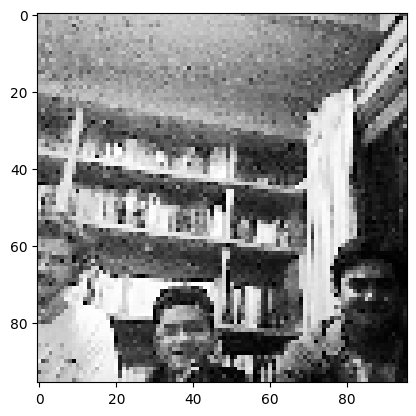

In [7]:

image = np.zeros((96,96))
d=0
for y in range(0,96):
  for x in range(0,96):
    image[y,x] = HEXADECIMAL_BYTES[y*96+x]
print(image)
plt.imshow(image, cmap='gray', vmin=0, vmax=np.max(image))
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruir(bytes_data):
    img = np.zeros((96,96))
    for y in range(96):
        for x in range(96):
            img[y,x] = bytes_data[y*96+x]
    return img

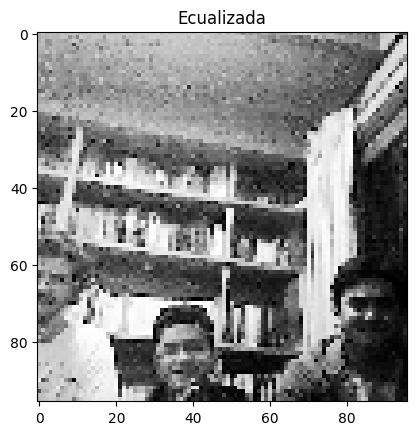

In [9]:
img_eq = reconstruir(HEXADECIMAL_BYTES)

plt.imshow(img_eq, cmap='gray', vmin=0, vmax=255)
plt.title("Ecualizada")
plt.show()

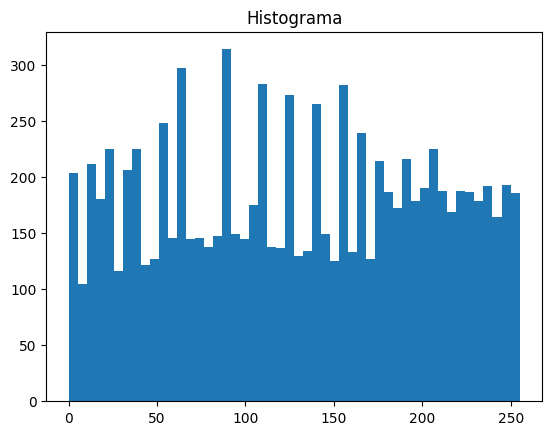

In [13]:


plt.hist(img_eq.flatten(), bins=50)
plt.title("Histograma")
plt.show()